# Disaster Tweets: NLP Classification

Text classification on the Kaggle *Natural Language Processing with Disaster Tweets* competition. Location normalisation, keyword imputation via regex, text preprocessing, TF-IDF plus hand-built numeric features, Logistic Regression / Random Forest / LightGBM with Optuna tuning, 10-fold CV and error analysis.

*The notebook text is in Portuguese. An English summary of the approach and results is in the README of this folder.*

---

# NLP : Classificacao de Tweets de Desastres

Construir um modelo de aprendizado de maquina capaz de distinguir tweets que tratam de desastres reais daqueles que usam linguagem dramatica de forma figurada.

### Estrutura do Case

| Bloco | Descricao |
|---|---|
| **0** | Setup e carregamento |
| **1** | EDA : estrutura e qualidade dos dados |
| **2** | EDA : caracteristicas linguisticas |
| **3** | Normalizacao e agrupamento de `location` |
| **4** | Imputacao de `keyword` por extracao via regex |
| **5** | Preprocessamento textual |
| **6** | Engenharia de features |
| **7** | Vetorizacao e modelagem |
| **8** | Avaliacao e interpretabilidade |
| **9** | Geracao do submit |


---
## Bloco 0 : Setup e Carregamento

In [ ]:
!pip install nltk wordcloud lightgbm --quiet

In [ ]:
# Instalar Optuna para otimizacao de hiperparametros
!pip install optuna --quiet

In [ ]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, roc_curve,
    classification_report
)
from scipy.sparse import hstack, csr_matrix
import lightgbm as lgb

warnings.filterwarnings('ignore')

for pkg in ['stopwords', 'wordnet', 'punkt', 'punkt_tab', 'omw-1.4']:
    nltk.download(pkg, quiet=True)

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right': False,
})
PAL  = ['#3498DB', '#E74C3C', '#2ECC71', '#F39C12', '#9B59B6', '#1ABC9C']
SEED = 42



In [ ]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

train['is_train'] = True
test['is_train']  = False
df = pd.concat([train, test], ignore_index=True)

print(f'Train : {train.shape}')
print(f'Test  : {test.shape}')
print(f'Full  : {df.shape}')
df.head()

Train : (7613, 6)
Test  : (3263, 5)
Full  : (10876, 6)


,id,keyword,location,text,target,is_train
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1.0,True
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1.0,True
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1.0,True
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1.0,True
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1.0,True


---
## Bloco 1 : EDA : Estrutura e Qualidade dos Dados

In [ ]:
# 1.1 : Visao geral : tipos, nulos e amostra
miss     = train.isnull().sum()
miss_pct = (miss / len(train) * 100).round(1)
summary  = pd.DataFrame({
    'dtype'   : train.dtypes,
    'nulos'   : miss,
    'nulos_%' : miss_pct
})
print('=== TIPOS E NULOS (TRAIN) ===')
print(summary.to_string())
print()
display(train.sample(5, random_state=SEED))

=== TIPOS E NULOS (TRAIN) ===
           dtype  nulos  nulos_%
id         int64      0      0.0
keyword   object     61      0.8
location  object   2533     33.3
text      object      0      0.0
target     int64      0      0.0
is_train    bool      0      0.0



,id,keyword,location,text,target,is_train
2644,3796,destruction,NaN,So you have a new weapon that can cause un-ima...,1,True
2227,3185,deluge,NaN,The f$&amp;@ing things I do for #GISHWHES Just...,0,True
5448,7769,police,UK,DT @georgegalloway: RT @Galloway4Mayor: ÛÏThe...,1,True
132,191,aftershock,NaN,Aftershock back to school kick off was great. ...,0,True
6845,9810,trauma,"Montgomery County, MD",in response to trauma Children of Addicts deve...,0,True


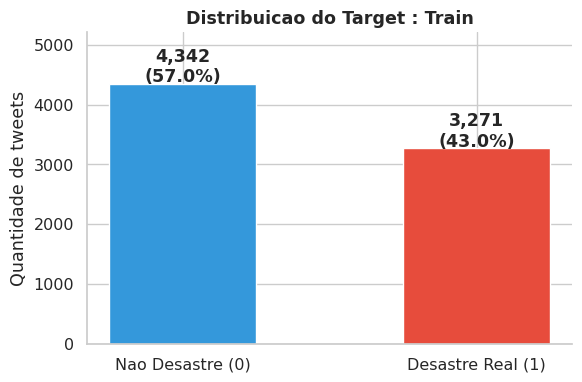

In [ ]:
# 1.2 : Distribuicao do target
fig, ax = plt.subplots(figsize=(6, 4))
counts = train['target'].value_counts()
bars = ax.bar(
    ['Nao Desastre (0)', 'Desastre Real (1)'],
    counts.values,
    color=[PAL[0], PAL[1]],
    edgecolor='white', width=0.5
)
for bar in bars:
    pct = bar.get_height() / len(train) * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f'{bar.get_height():,}\n({pct:.1f}%)',
        ha='center', fontweight='bold'
    )
ax.set_title('Distribuicao do Target : Train', fontweight='bold')
ax.set_ylabel('Quantidade de tweets')
ax.set_ylim(0, counts.max() * 1.2)
plt.tight_layout()
plt.show()

### Balanceamento do Target

As classes sao levemente desbalanceadas, entao o **F1-Score** sera a metrica principal, pois pondera precisao e recall de forma equilibrada para classes levemente desbalanceadas.

vou ver a qualidade das colunas `keyword` e `location`, que possuem nulos expressivos e alta cardinalidade.

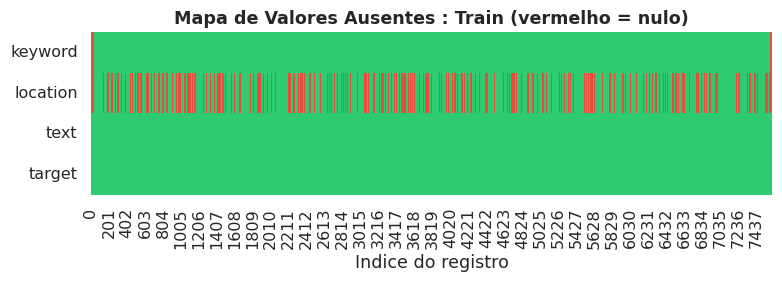

In [ ]:
# Mapa de nulos
fig, ax = plt.subplots(figsize=(8, 3))
miss_data = train[['keyword', 'location', 'text', 'target']].isnull()
sns.heatmap(
    miss_data.T,
    cmap=['#2ECC71', '#E74C3C'],
    cbar=False, ax=ax,
    yticklabels=True
)
ax.set_title('Mapa de Valores Ausentes : Train (vermelho = nulo)', fontweight='bold')
ax.set_xlabel('Indice do registro')
plt.tight_layout()
plt.show()

### Valores Ausentes

- **`text` :** zero nulos. Coluna principal integra e pronta para uso.
- **`keyword` :** 61 nulos (0.8%). Volume pequeno, e a keyword e derivavel do proprio texto. Serao tratados no Bloco 4 via extracao por regex.
- **`location` :** 2.533 nulos (33.3%). Volume alto com 4.521 valores unicos e grafias inconsistentes. Requer pipeline de normalizacao dedicado (Bloco 3).


### Keywords por Classe

Tweets de desastre real concentram keywords como `wildfire`, `earthquake`, `flood` e `explosion`, diretamente ligadas a eventos catastroficos. Ja tweets de nao-desastre frequentemente incluem `ablaze`, `body bags` e `massacre`, palavras que soam dramaticas mas aparecem em contextos figurados ou de entretenimento

 A keyword sera muito util na predicao; os nulos serao imputados no Bloco 4.

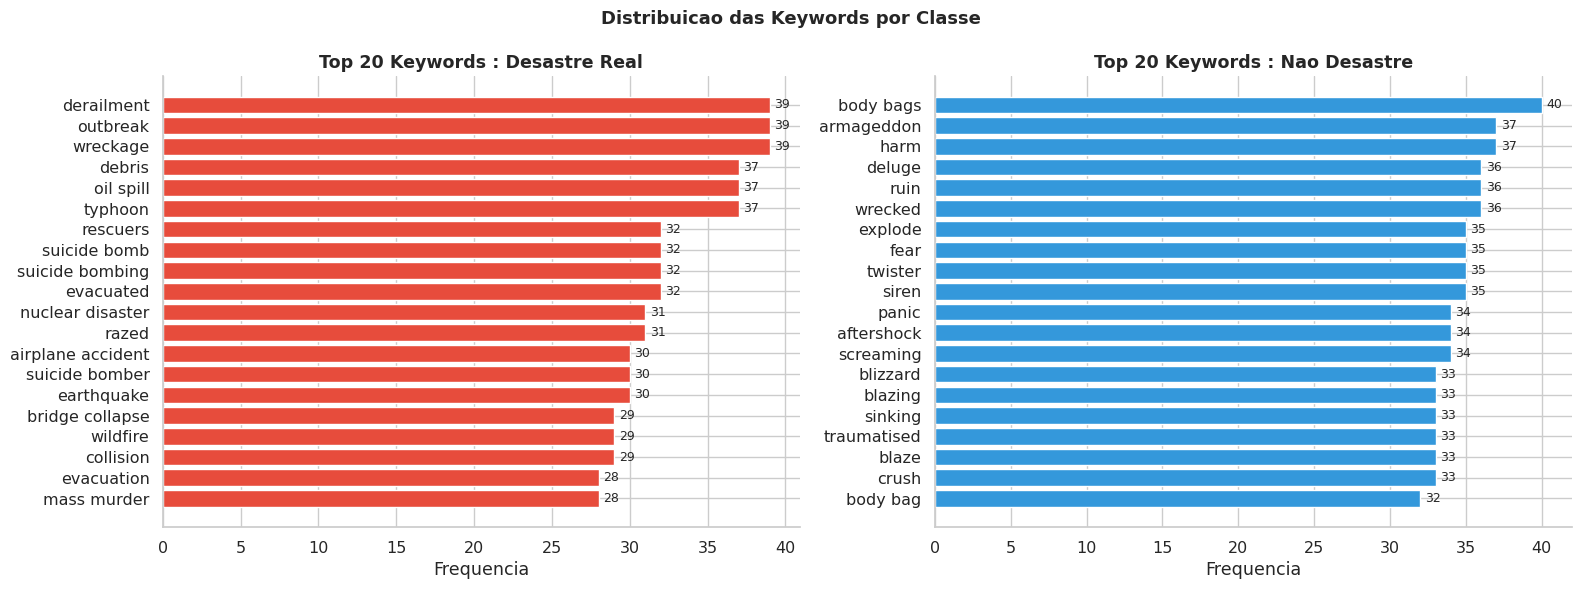

In [ ]:
# 1.4 : Top 20 keywords por classe
kw_train = train[train['keyword'].notna()].copy()
kw_train['keyword'] = kw_train['keyword'].str.replace('%20', ' ').str.lower()

top_disaster   = kw_train[kw_train['target'] == 1]['keyword'].value_counts().head(20)
top_nodisaster = kw_train[kw_train['target'] == 0]['keyword'].value_counts().head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (data, title, color) in zip(axes, [
    (top_disaster,   'Top 20 Keywords : Desastre Real',  PAL[1]),
    (top_nodisaster, 'Top 20 Keywords : Nao Desastre',   PAL[0]),
]):
    bars = ax.barh(data.index[::-1], data.values[::-1], color=color, edgecolor='white')
    for bar in bars:
        ax.text(
            bar.get_width() + 0.3,
            bar.get_y() + bar.get_height() / 2,
            str(int(bar.get_width())),
            va='center', fontsize=9
        )
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Frequencia')
plt.suptitle('Distribuicao das Keywords por Classe', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

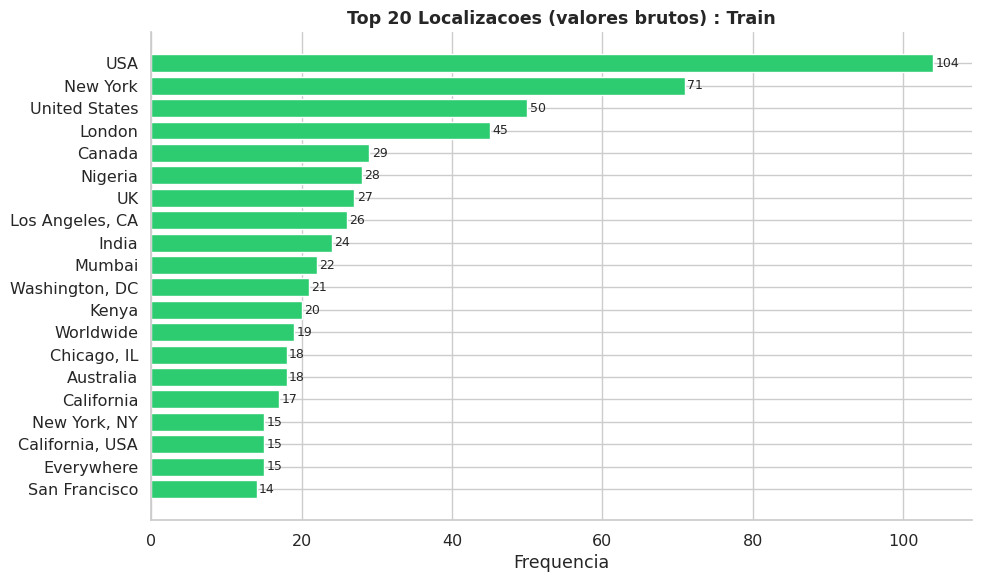

In [ ]:
# Top 20 localizacoes brutas
fig, ax = plt.subplots(figsize=(10, 6))
top_loc = train['location'].value_counts().head(20)
bars = ax.barh(top_loc.index[::-1], top_loc.values[::-1], color=PAL[2], edgecolor='white')
for bar in bars:
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        str(int(bar.get_width())),
        va='center', fontsize=9
    )
ax.set_title('Top 20 Localizacoes (valores brutos) : Train', fontweight='bold')
ax.set_xlabel('Frequencia')
plt.tight_layout()
plt.show()

### Alta Cardinalidade de `location`

`USA` e `United States` representam a mesma entidade mas aparecem como categorias separadas. O mesmo ocorre com `New York` e `New York, NY`, `Los Angeles` e `Los Angeles, CA`. .

Fazer normalizacao que padronize grafias, mapeie cidades e estados para seus paises e agrupe tudo em grupos de paises

---
## Bloco 2 : EDA : Caracteristicas Linguisticas do Texto

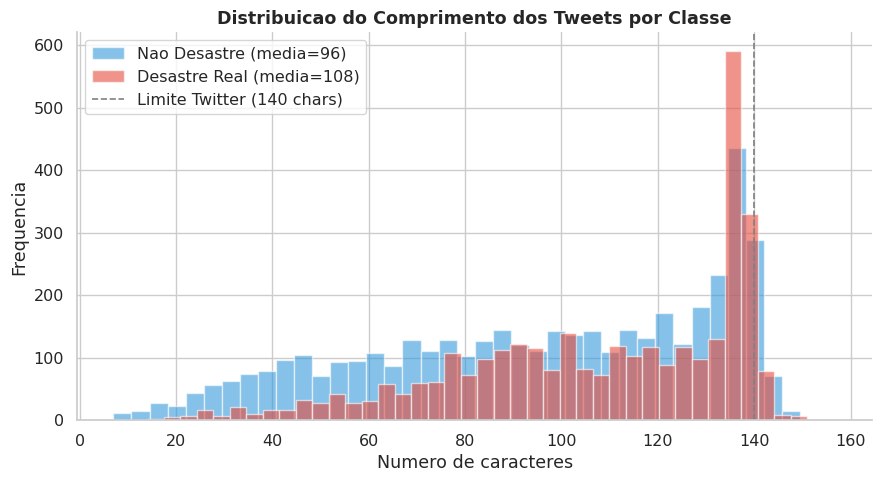

In [ ]:
# 2.1 : Distribuicao do comprimento em caracteres por classe
train['char_len'] = train['text'].str.len()

fig, ax = plt.subplots(figsize=(9, 5))
for label, color, name in [
    (0, PAL[0], 'Nao Desastre'),
    (1, PAL[1], 'Desastre Real')
]:
    subset = train[train['target'] == label]['char_len']
    ax.hist(
        subset, bins=40, alpha=0.6, color=color,
        label=f'{name} (media={subset.mean():.0f})',
        edgecolor='white'
    )
ax.axvline(140, color='gray', linestyle='--', linewidth=1.2, label='Limite Twitter (140 chars)')
ax.set_title('Distribuicao do Comprimento dos Tweets por Classe', fontweight='bold')
ax.set_xlabel('Numero de caracteres')
ax.set_ylabel('Frequencia')
ax.legend()
plt.tight_layout()
plt.show()

### Comprimento dos Tweets

Tweets de desastre real tendem a ser ligeiramente mais longos : a media e de ~103 caracteres contra ~96 nos nao-desastres. Relatos de eventos reais geralmente incluem localizacao, detalhes e contexto, enquanto tweets figurados costumam ser mais concisos.

**feature nova :** `char_len`

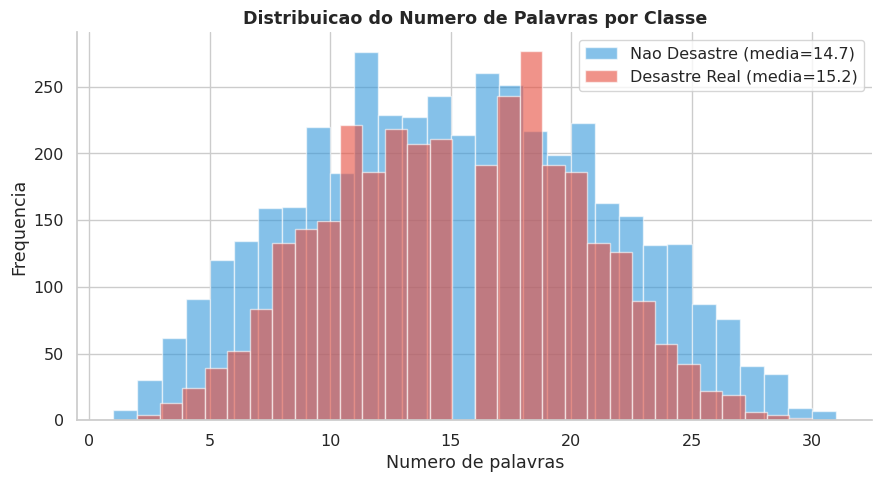

In [ ]:
# 2.2 : Distribuicao do numero de palavras por classe
train['word_count'] = train['text'].str.split().str.len()

fig, ax = plt.subplots(figsize=(9, 5))
for label, color, name in [
    (0, PAL[0], 'Nao Desastre'),
    (1, PAL[1], 'Desastre Real')
]:
    subset = train[train['target'] == label]['word_count']
    ax.hist(
        subset, bins=30, alpha=0.6, color=color,
        label=f'{name} (media={subset.mean():.1f})',
        edgecolor='white'
    )
ax.set_title('Distribuicao do Numero de Palavras por Classe', fontweight='bold')
ax.set_xlabel('Numero de palavras')
ax.set_ylabel('Frequencia')
ax.legend()
plt.tight_layout()
plt.show()

### Numero de Palavras

a distribuicao de palavras segue o mesmo padrao do comprimento em caracteres

Vou tambem verificar a presenca de elementos estruturais : URLs, hashtags e mencoes.

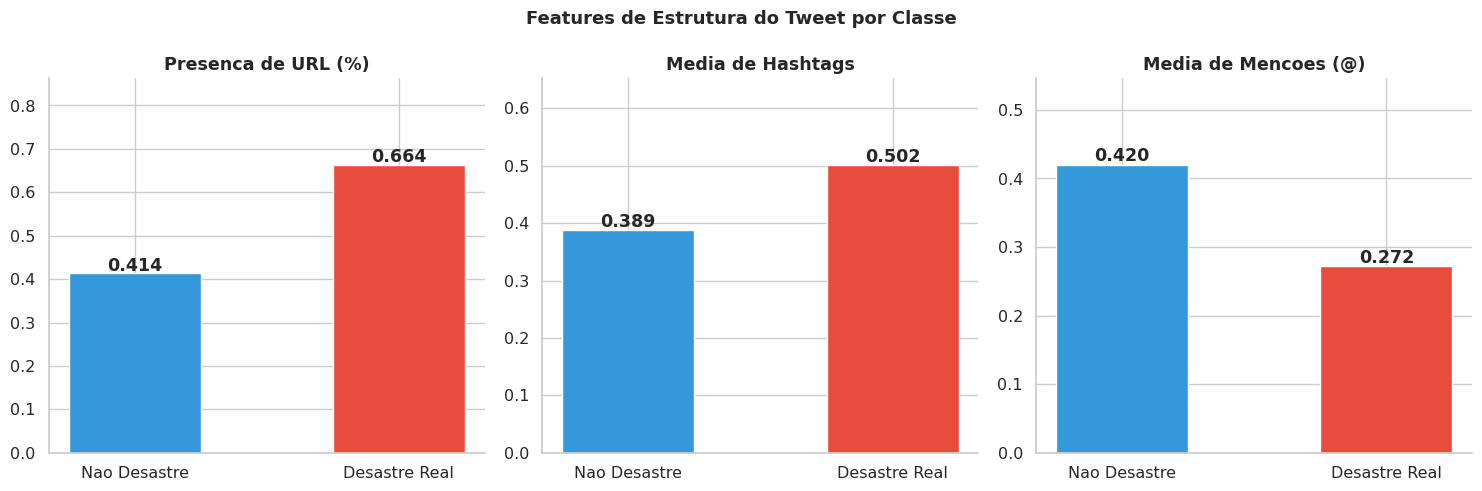

In [ ]:
# 2.3 : Frequencia de URLs, hashtags e mencoes por classe
train['has_url']       = train['text'].str.contains(r'https?://', regex=True).astype(int)
train['hashtag_count'] = train['text'].str.count(r'#\w+')
train['mention_count'] = train['text'].str.count(r'@\w+')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col, title in zip(
    axes,
    ['has_url', 'hashtag_count', 'mention_count'],
    ['Presenca de URL (%)', 'Media de Hashtags', 'Media de Mencoes (@)']
):
    vals = [train[train['target'] == c][col].mean() for c in [0, 1]]
    bars = ax.bar(
        ['Nao Desastre', 'Desastre Real'],
        vals, color=[PAL[0], PAL[1]],
        edgecolor='white', width=0.5
    )
    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{v:.3f}', ha='center', fontweight='bold'
        )
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, max(vals) * 1.3)
plt.suptitle('Features de Estrutura do Tweet por Classe', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### URLs, Hashtags e Mencoes

- **URLs :** tweets de desastre real apresentam maior proporcao de links. Usuarios compartilham noticias e fontes durante emergencias.
- **Hashtags :** tweets de desastre usam ligeiramente mais hashtags para ampliar alcance (#earthquake, #wildfire).
- **Mencoes (@) :** sem diferenca relevante entre as classes.

vou criar entao `has_url` e `hashtag_count`

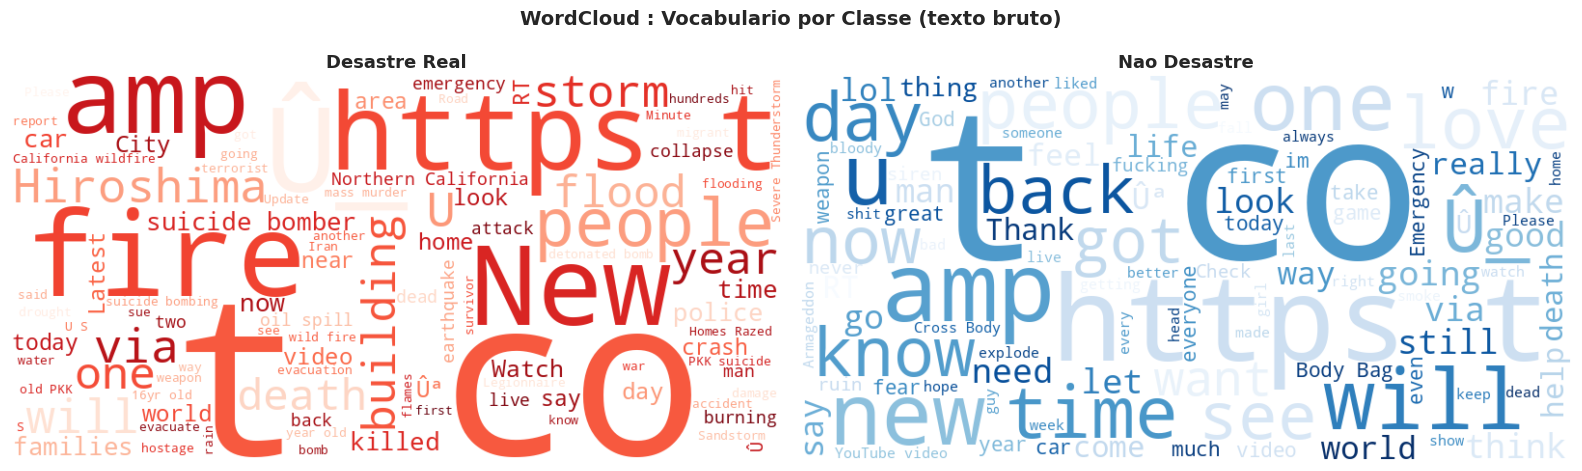

In [ ]:
# 2.4 : WordCloud : desastre real vs nao-desastre (texto bruto)
def make_wordcloud(text_series, colormap, title, ax):
    text = ' '.join(text_series.dropna())
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap=colormap,
        max_words=100,
        random_state=SEED
    ).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.axis('off')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
make_wordcloud(train[train['target'] == 1]['text'], 'Reds',  'Desastre Real',  axes[0])
make_wordcloud(train[train['target'] == 0]['text'], 'Blues', 'Nao Desastre',   axes[1])
plt.suptitle('WordCloud : Vocabulario por Classe (texto bruto)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Insight 2.4 : WordCloud (texto bruto)

A nuvem de desastre real e dominada por termos concretos de emergencia : `fire`, `flood`, `people`, `killed`, `dead`, `storm`, `earthquake`. A nuvem de nao-desastre mostra vocabulario mais difuso : `like`, `suicide`, `love`, `burning`, palavras com duplo significado que tornam a classificacao ambigua.

Ha stopwords e residuos de URL (`the`, `http`, `t`) que serao removidos no Bloco 5.

tem um grande constraste nos vocabularios

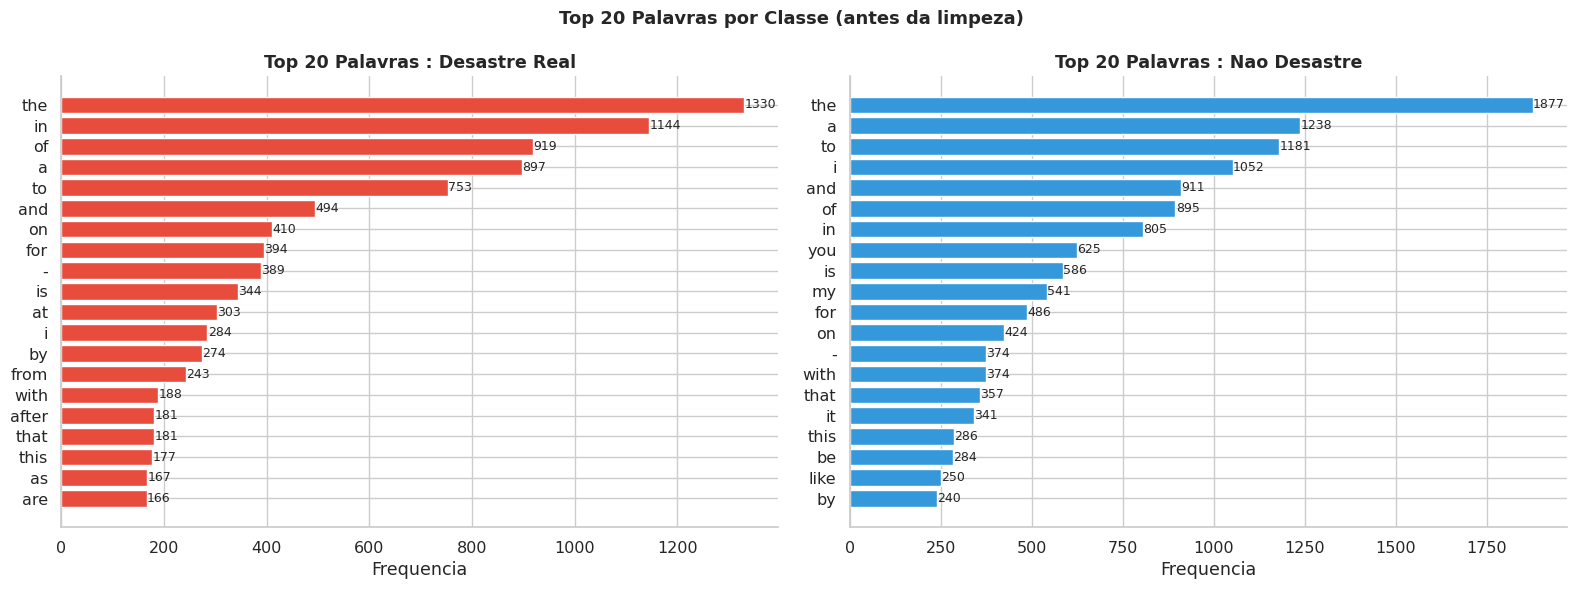

In [ ]:
# 2.5 : Top 20 palavras mais frequentes por classe (texto bruto)
from collections import Counter

def get_top_words(series, n=20):
    all_words = ' '.join(series.dropna()).lower().split()
    return pd.Series(Counter(all_words)).sort_values(ascending=False).head(n)

top_dis   = get_top_words(train[train['target'] == 1]['text'])
top_nodis = get_top_words(train[train['target'] == 0]['text'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (data, title, color) in zip(axes, [
    (top_dis,   'Top 20 Palavras : Desastre Real', PAL[1]),
    (top_nodis, 'Top 20 Palavras : Nao Desastre',  PAL[0]),
]):
    bars = ax.barh(data.index[::-1], data.values[::-1], color=color, edgecolor='white')
    for bar in bars:
        ax.text(
            bar.get_width() + 1,
            bar.get_y() + bar.get_height() / 2,
            str(int(bar.get_width())),
            va='center', fontsize=9
        )
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Frequencia')
plt.suptitle('Top 20 Palavras por Classe (antes da limpeza)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

###  Palavras mais Frequentes (bruto)

As palavras mais frequentes em ambas as classes sao dominadas por stopwords (`the`, `a`, `in`, `of`) e elementos de URL (`http`, `t.co`)

---
## Bloco 3 : Normalizacao e Agrupamento de `location`



In [ ]:
# 3.1 : Diagnostico de tipos de ruido em location
df_loc = df['location'].dropna().str.lower().str.strip()

diagnostico = {
    'Total nao nulos'              : len(df_loc),
    'Valores unicos'               : df_loc.nunique(),
    'Com chars nao-ASCII (emojis)' : df_loc.str.contains(r'[^\x00-\x7F]', regex=True).sum(),
    'Coordenadas GPS'              : df_loc.str.contains(r'\d+\.\d+.*\d+\.\d+', regex=True).sum(),
    'Valores genericos (worldwide,earth...)' : df_loc.isin([
        'worldwide','everywhere','earth','world','global',
        'the internet','internet','online','universe',
        'here','home','world wide','planet earth'
    ]).sum(),
    'Com 2 chars ou menos'         : (df_loc.str.len() <= 2).sum(),
}

print('=== TIPOS DE RUIDO EM LOCATION ===')
for k, v in diagnostico.items():
    print(f'  {k:<45} : {v:,}')

=== TIPOS DE RUIDO EM LOCATION ===
  Total nao nulos                               : 7,238
  Valores unicos                                : 4,263
  Com chars nao-ASCII (emojis)                  : 140
  Coordenadas GPS                               : 48
  Valores genericos (worldwide,earth...)        : 140
  Com 2 chars ou menos                          : 140


`location` possui 4,263 valores unicos com variacoes de grafia do mesmo pais (`USA`, `United States`, `U.S.A`), cidades sem mencao ao pais (`New York`, `London`), ruidos como emojis, coordenadas GPS e valores genericos (`Worldwide`, `Earth`) e 33% de nulos.

vou criar `location_group` com 18 grupos geograficos nomeados + `generic` + `unknown`

Observacao: a coluna contem muitos valores que nao sao localidades reais (frases, emojis, piadas).


In [ ]:
INVALID_PATTERN = re.compile(
    r'[^\x00-\x7F]'           # emojis e unicode corrompido
    r'|\d{1,3}\.\d+.*\d{1,3}\.\d+'  # coordenadas GPS
    r'|^.{1,2}$'              # valores com 2 chars ou menos (ss, ??)
    r'|^[^a-z]+$'             # apenas simbolos/numeros sem letra (??????, 304)
    r'|pedophile'             # conteudo ofensivo sem valor geografico
)

GENERIC_SET = {
    'worldwide','everywhere','earth','world','global',
    'the internet','internet','online','universe','here',
    'home','everywhere i go','world wide','planet earth',
    'narnia','gotham city','hell','heaven','road to the billionaires club', 'in the word of god', 'mad as hell',
'happily married with 2 kids', 'breaking news', 'does it really matter!',
'anonymous', 'the universe', 'jupiter', 'here.'
}

# Ordenado do mais especifico para o mais generico
LOCATION_RULES = [
    ('usa', re.compile(
        r'\b(usa|united states|u\.s\.a|u\.s\.|u\.s\b'
        r'|america(?!n south)|united states of america)\b'
        r'|\b(new york city?|nyc|los angeles|chicago|san francisco|seattle'
        r'|boston|atlanta|dallas|houston|miami|nashville|memphis|philadelphia'
        r'|detroit|portland|austin|baltimore|phoenix|denver|orlando|las vegas'
        r'|minneapolis|pittsburgh|new orleans|sacramento|san diego|san jose'
        r'|kansas city|washington dc|washington d\.c\.|southern california'
        r'|paterson new jersey|new york new york|bend, oregon|oklahoma city'
        r'|oakland|naperville|tulsa oklahoma|mo\.city|swmo|dmv)\b'
        r'|^(california|texas|florida|new york|illinois|ohio|georgia|michigan'
        r'|pennsylvania|colorado|oregon|tennessee|north carolina|virginia'
        r'|new jersey|arizona|massachusetts|washington state|indiana|maryland'
        r'|missouri|wisconsin|minnesota|connecticut|south carolina|nevada|iowa'
        r'|arkansas|utah|kansas|hawaii|alaska|nebraska|idaho|west virginia'
        r'|new mexico|maine|oklahoma|kentucky|louisiana|mississippi|alabama'
        r'|rhode island|delaware|vermont|wyoming|montana|north dakota'
        r'|south dakota|new hampshire|midwest|east coast|puerto rico|rocky mountains|ma|republic of texas)$'
        r'|,\s*(ca|ny|tx|fl|il|oh|ga|mi|pa|co|or|tn|nc|va|nj|az|ma|wa|in'
        r'|md|mo|wi|mn|ct|sc|nv|ia|ar|ut|ks|hi|ak|ne|id|wv|nm|me|ok|ky|la'
        r'|ms|al|ri|de|vt|wy|mt|nd|sd|dc)\s*$' # Include 'dc' for Washington, D.C. abbreviations
        r'|^(us|ny|pa|nj|ca|fl)$'
        r'|washington,\s*d\.c\.?'          # Washington, D.C. e Washington, D.C
        r'|^new york,\s*new york$'          # New York, New York
    )),
    ('uk', re.compile(
        r'\b(uk|united kingdom|england|britain|great britain|scotland'
        r'|wales|northern ireland|u\.k\.)\b'
        r'|^(london|manchester|birmingham|leeds|liverpool|glasgow|edinburgh'
        r'|bristol|sheffield|nottingham|leicester|coventry|bradford|cardiff'
        r'|belfast|newcastle|hull|stoke|derby|southampton|reading|oxford'
        r'|cambridge|exeter|york|brighton|bath|portsmouth|paignton|macclesfield)$'
    )),
    ('canada', re.compile(
        r'\b(canada|canadian)\b'
        r'|^(toronto|vancouver|montreal|calgary|edmonton|ottawa|winnipeg'
        r'|quebec city|halifax|hamilton)$'
        r'|\b(ontario|alberta|british columbia|quebec|nova scotia'
        r'|saskatchewan|manitoba)\b'
        r'|,\s*(ab|bc|on|qc)\s*$'
        r'|paterson'                        # cidade de New Jersey
    )),
    ('australia', re.compile(
        r'\b(australia|australian)\b'
        r'|^(sydney|melbourne|brisbane|perth|adelaide|canberra|darwin'
        r'|hobart|gold coast)$'
        r'|\b(queensland|new south wales|victoria(?! bc| british))\b'
    )),
    ('india', re.compile(
        r'\b(india|indian)\b'
        r'|^(mumbai|delhi|bangalore|chennai|kolkata|hyderabad|pune'
        r'|ahmedabad|surat|jaipur|new delhi|new delhi delhi)$'
        r'|\b(maharashtra|karnataka|tamil nadu|west bengal|telangana)\b'
        r'|new delhi'
    )),
    ('nigeria', re.compile(
        r'\b(nigeria|nigerian)\b'
        r'|^(lagos|abuja|kano|ibadan|benin city|port harcourt|fct, abuja)$'
    )),
    ('kenya', re.compile(
        r'\b(kenya|kenyan|nairobi)\b'
    )),
    ('south_africa', re.compile(
        r'\b(south africa|south african)\b'
        r'|^(johannesburg|cape town|durban|pretoria)$'
    )),
    ('indonesia', re.compile(
        r'\b(indonesia|indonesian|jakarta)\b'
    )),
    ('philippines', re.compile(
        r'\b(philippines|philippine|filipino|manila|cebu)\b'
    )),
    ('ireland', re.compile(
        r'\b(ireland|irish|dublin)\b'
    )),
    ('singapore', re.compile(
        r'\bsingapore\b'
    )),
    ('pakistan', re.compile(
        r'\b(pakistan|pakistani|karachi|lahore|islamabad)\b'
    )),
    ('germany', re.compile(
        r'\b(germany|german|deutschland|berlin|munich|hamburg|frankfurt)\b'
    )),
    ('france', re.compile(
        r'\b(france|french|paris)\b'
    )),
    ('brazil', re.compile(
        r'\b(brazil|brasil|brazilian|sao paulo|rio de janeiro)\b'
    )),
    ('new_zealand', re.compile(
        r'\b(new zealand|auckland|wellington|christchurch)\b'
    )),
    ('malaysia', re.compile(
        r'\b(malaysia|malaysian|kuala lumpur)\b'
    )),
    ('other_country', re.compile(
        r'\b(china|japan|italy|switzerland|turkey|spain|mexico|argentina'
        r'|venezuela|jamaica|hong kong|dubai|uae|iraq|afghanistan|netherlands'
        r'|holland|ethiopia|tanzania|zimbabwe|egypt|south korea|korea|sweden'
        r'|norway|denmark|finland|belgium|austria|poland|czech|greece|portugal'
        r'|thailand|vietnam|myanmar|bangladesh|nepal|sri lanka|ghana|barbados'
        r'|trinidad|uganda|cameroon|senegal|morocco|algeria|saudi arabia'
        r'|jordan|israel|iran|ukraine|russia|romania|hungary|serbia|peru|chile'
        r'|colombia|ecuador|bolivia|paraguay|uruguay|tokyo|beijing|shanghai'
        r'|rome|madrid|amsterdam|brussels|stockholm|oslo|copenhagen|helsinki'
        r'|athens|lisbon|warsaw|budapest|seoul|bangkok|taipei|costa rica|dominican republic|panama|guatemala|el salvador|honduras|nicaragua|cuba|puerto rico|haiti|jamaica|ecuador|bolivia|paraguay|uruguay|venezuela|colombia|peru|chile|argentina|bolivia|guyana|suriname|french guiana|belize|bahamas|bermuda|cayman islands|aruba|curacao|barbados|trinidad and tobago|dominica|grenada|st lucia|st vincent|antigua|st kitts|virgin islands|mongolia|kazakhstan|uzbekistan|turkmenistan|kyrgyzstan|tajikistan|georgia|armenia|azerbaijan|cyprus|malta|albania|bosnia|croatia|montenegro|north macedonia|slovenia|slovakia|estonia|latvia|lithuania|iceland|luxembourg|liechtenstein|monaco|andorra|san marino|vatican city|maldives|sri lanka|bhutan|cambodia|laos|malaysia|myanmar|philippines|vietnam|indonesia|brunei|east timor|papua new guinea|fiji|solomon islands|vanuatu|new caledonia|samoa|tonga|kiribati|micronesia|marshall islands|nauru|palau|tuvalu|algeria|angola|benin|botswana|burkina faso|burundi|cabo verde|cameroon|central african republic|chad|comoros|congo|djibouti|equatorial guinea|eritrea|eswatini|gabon|gambia|ghana|guinea|guinea-bissau|ivory coast|lesotho|liberia|libya|madagascar|malawi|mali|mauritania|mauritius|mozambique|namibia|niger|rwanda|sao tome and principe|senegal|seychelles|sierra leone|somalia|south sudan|sudan|tanzania|togo|tunisia|uganda|zambia|zimbabwe|asia|europe|geneva)\b'
    )),
]


def normalize_location(loc):
    """Mapeia valor bruto de location para um grupo geografico."""
    if pd.isna(loc):
        return 'unknown'
    loc = str(loc).lower().strip()
    if not loc or INVALID_PATTERN.search(loc):
        return 'unknown'
    if loc in GENERIC_SET:
        return 'generic'
    for group, pattern in LOCATION_RULES:
        if pattern.search(loc):
            return group
    return 'other'


df['location_group'] = df['location'].apply(normalize_location)
print('location_group criada com sucesso!')
print(df['location_group'].value_counts())

location_group criada com sucesso!
location_group
unknown          4043
usa              2442
other            2434
uk                417
other_country     377
canada            269
generic           211
india             141
australia         120
nigeria           102
kenya              49
ireland            37
south_africa       34
indonesia          34
philippines        34
pakistan           29
new_zealand        21
brazil             20
germany            19
france             18
singapore          15
malaysia           10
Name: count, dtype: int64


In [ ]:
# Amostra dos valores originais de 'location' que ainda estao em 'other'
print("Amostra de 20 localizacoes que ainda estao na categoria 'other':")
display(df[df['location_group'] == 'other']['location'].value_counts().head(20))

Amostra de 20 localizacoes que ainda estao na categoria 'other':


,count
location,
Subconscious LA,4
Your screen,4
Inexpressible Island,3
Azeroth,3
CA via Brum,3
U.K.,3
Financial News and Views,3
they/them,3
Mountains,3


### Limitacao do mapeamento

O mapeamento de cidades e estados para paises foi feito manualmente a partir dos valores mais frequentes. Uma abordagem mais escalavel seria usar um gazetteer (ex. `geonamescache`) ou um geocoder para resolver automaticamente as localidades restantes.

In [ ]:
# Listar os 50 valores mais frequentes que ainda permanecem em 'other'
print("Top 50 localizacoes mais frequentes que ainda estao na categoria 'other':")
display(df[df['location_group'] == 'other']['location'].value_counts().head(50))

Top 50 localizacoes mais frequentes que ainda estao na categoria 'other':


,count
location,
Subconscious LA,4
Your screen,4
Inexpressible Island,3
Azeroth,3
CA via Brum,3
U.K.,3
Financial News and Views,3
they/them,3
Mountains,3


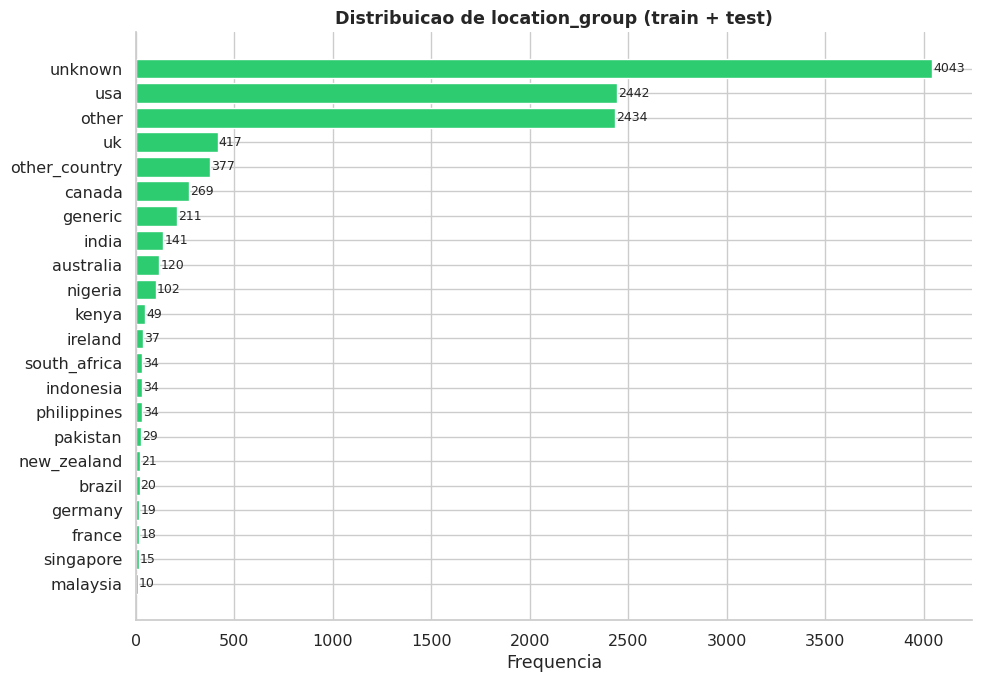

In [ ]:
# 3.3 : Distribuicao dos grupos apos normalizacao
fig, ax = plt.subplots(figsize=(10, 7))
grp_counts = df['location_group'].value_counts()
bars = ax.barh(grp_counts.index[::-1], grp_counts.values[::-1], color=PAL[2], edgecolor='white')
for bar in bars:
    ax.text(
        bar.get_width() + 5,
        bar.get_y() + bar.get_height() / 2,
        str(int(bar.get_width())),
        va='center', fontsize=9
    )
ax.set_title('Distribuicao de location_group (train + test)', fontweight='bold')
ax.set_xlabel('Frequencia')
plt.tight_layout()
plt.show()

### Grupos Geograficos

A normalizacao reduziu 4.521 categorias para 21 grupos

Os grupos `usa` e `uk` dominam, refletindo a base de usuarios do Twitter em lingua inglesa. O grupo `unknown` são  nulos, emojis e coordenadas GPS.  O grupo `other` concentra as localidades que nao foram mapeadas manualmente (ver nota no Bloco 3).

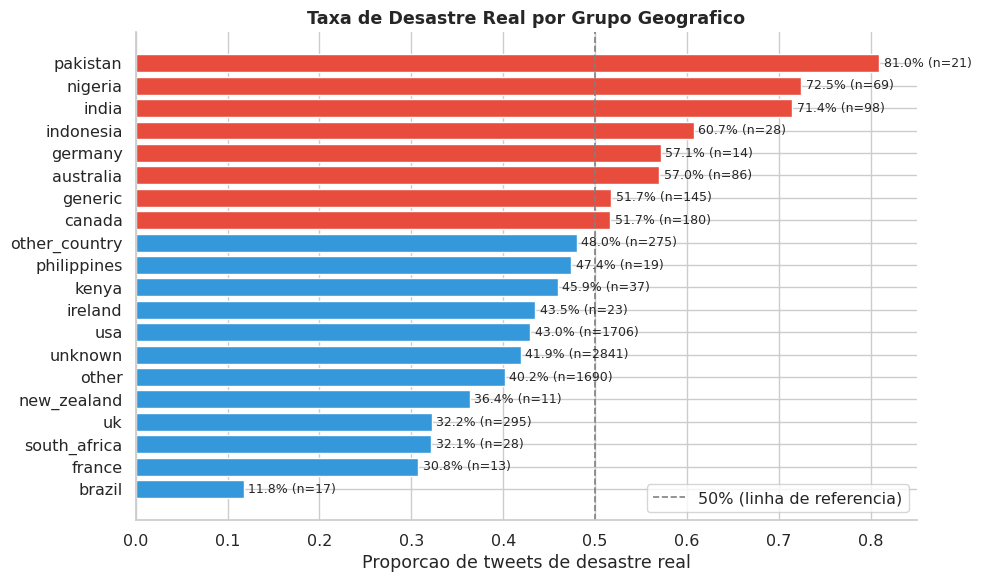

In [ ]:
# Taxa de desastre real por grupo geografico (somente train)
train_loc = df[df['is_train']].copy()
disaster_rate = (
    train_loc.groupby('location_group')['target']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'disaster_rate', 'count': 'total'})
    .query('total >= 10')
    .sort_values('disaster_rate', ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
colors = [PAL[1] if v >= 0.5 else PAL[0] for v in disaster_rate['disaster_rate']]
bars = ax.barh(disaster_rate.index, disaster_rate['disaster_rate'], color=colors, edgecolor='white')
ax.axvline(0.5, color='gray', linestyle='--', linewidth=1.2, label='50% (linha de referencia)')
for bar, (_, row) in zip(bars, disaster_rate.iterrows()):
    ax.text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f'{bar.get_width():.1%} (n={int(row["total"])})',
        va='center', fontsize=9
    )
ax.set_title('Taxa de Desastre Real por Grupo Geografico', fontweight='bold')
ax.set_xlabel('Proporcao de tweets de desastre real')
ax.legend()
ax.set_xlim(0, 0.85)
plt.tight_layout()
plt.show()

### Insight 3.4 : Sinal Preditivo de location_group

O grupo geografico carrega sinal preditivo real. Grupos como `pakistan`, `nigeria` e `india` apresentam maior proporcao de tweets de desastre real, possivelmente relacionados a conflitos, desastres naturais etc

vou fazer `location_group`  codificada via One-Hot

In [ ]:
# 3.5 : Cobertura : antes vs depois da normalizacao
print('=== COBERTURA DA NORMALIZACAO ===')
print(f'Categorias antes (location bruta)  : {df["location"].nunique():,}')
print(f'Categorias depois (location_group) : {df["location_group"].nunique():,}')
print()
total_full = len(df)
mapeados   = (df['location_group'].isin([g for g, _ in LOCATION_RULES])).sum()
unknown    = (df['location_group'] == 'unknown').sum()
other      = (df['location_group'] == 'other').sum()
generic    = (df['location_group'] == 'generic').sum()
print(f'Mapeados para grupo nomeado : {mapeados:,} ({mapeados/total_full*100:.1f}%)')
print(f'other (nao mapeado)         : {other:,}  ({other/total_full*100:.1f}%)')
print(f'generic (sem sentido geo)   : {generic:,}  ({generic/total_full*100:.1f}%)')
print(f'unknown (nulo ou ruido)     : {unknown:,}  ({unknown/total_full*100:.1f}%)')

=== COBERTURA DA NORMALIZACAO ===
Categorias antes (location bruta)  : 4,521
Categorias depois (location_group) : 22

Mapeados para grupo nomeado : 4,188 (38.5%)
other (nao mapeado)         : 2,434  (22.4%)
generic (sem sentido geo)   : 211  (1.9%)
unknown (nulo ou ruido)     : 4,043  (37.2%)


---
## Bloco 4 : Imputacao de `keyword` por Extracao via Regex

**Problema :** 61 nulos em train e 26 em test.

**Regular Expressions:**  uma linguagem formal para descrever padrões em texto. Uma expressão regular é composta por símbolos que representam regras : . casa qualquer caractere, * e + indicam repetição, | funciona como "ou", [] define um conjunto de caracteres aceitos, ^ e $ marcam início e fim da string, e \b representa a fronteira entre uma palavra e o que vem ao redor dela. O motor de regex percorre a string testando se algum trecho casa com o padrão definido, retornando o match encontrado ou indicando ausência

**Estrategia :**
1. Ordenar as 221 keywords por comprimento decrescente (frases longas tem prioridade : `suicide bomber` antes de `suicide bomb`)
2. Para keyword de uma palavra : busca `\bkeyword\b` (word boundary)
3. Para keyword de multiplas palavras : busca substring exata
4. Primeiro match vence
5. Se nenhuma keyword e encontrada no texto : imputa `unknown`

In [ ]:
# Construcao da lista de keywords ordenada por comprimento
all_keywords = (
    pd.concat([train['keyword'], test['keyword']])
    .dropna()
    .str.replace('%20', ' ', regex=False)
    .str.lower()
    .str.strip()
    .unique()
)
# Ordena por comprimento decrescente : frases longas tem prioridade
all_keywords_sorted = sorted(all_keywords, key=len, reverse=True)

print(f'Total de keywords unicas : {len(all_keywords_sorted)}')
print()
print('Top 10 mais longas (terao prioridade no match) :')
for kw in all_keywords_sorted[:10]:
    print(f'  "{kw}"')

Total de keywords unicas : 221

Top 10 mais longas (terao prioridade no match) :
  "radiation emergency"
  "chemical emergency"
  "emergency services"
  "structural failure"
  "airplane accident"
  "buildings burning"
  "buildings on fire"
  "burning buildings"
  "first responders"
  "natural disaster"


In [ ]:
# Funcao de extracao por regex
def extract_keyword_from_text(text, keywords):
    """Retorna a primeira keyword encontrada no texto.
    Prioriza frases longas. Retorna None se nenhuma for encontrada."""
    text_lower = str(text).lower()
    for kw in keywords:
        if ' ' in kw:
            if kw in text_lower:
                return kw
        else:
            if re.search(r'\b' + re.escape(kw) + r'\b', text_lower):
                return kw
    return None


# Aplicacao no df completo
mask_null = df['keyword'].isnull()
df.loc[mask_null, 'keyword_extracted'] = df.loc[mask_null, 'text'].apply(
    lambda t: extract_keyword_from_text(t, all_keywords_sorted)
)

# keyword_was_null : flag de ausencia original
df['keyword_was_null'] = mask_null.astype(int)

# keyword_final : hierarquia de preenchimento
df['keyword_final'] = df['keyword'].str.replace('%20', ' ', regex=False).str.lower().str.strip()
df.loc[mask_null & df['keyword_extracted'].notna(), 'keyword_final'] =     df.loc[mask_null & df['keyword_extracted'].notna(), 'keyword_extracted']
df['keyword_final'] = df['keyword_final'].fillna('unknown')

# Atualiza train e test a partir do df
train = df[df['is_train']].copy()
test  = df[~df['is_train']].copy()

print('keyword_final criada com sucesso!')
print()
print('=== COBERTURA DA EXTRACAO (TRAIN) ===')
mask_null_train = train['keyword'].isnull()
extraiu  = (mask_null_train & train['keyword_final'].ne('unknown')).sum()
unknown  = (mask_null_train & train['keyword_final'].eq('unknown')).sum()
print(f'Total nulos originais : {mask_null_train.sum()}')
print(f'Extraiu por regex     : {extraiu} ({extraiu/mask_null_train.sum()*100:.1f}%)')
print(f'Permanece unknown     : {unknown} ({unknown/mask_null_train.sum()*100:.1f}%)')
print()

keyword_final criada com sucesso!

=== COBERTURA DA EXTRACAO (TRAIN) ===
Total nulos originais : 61
Extraiu por regex     : 45 (73.8%)
Permanece unknown     : 16 (26.2%)



In [ ]:
# Visualizacao : exemplos de imputacao
print('=== EXEMPLOS DE IMPUTACAO ===')
print()
amostra = df[mask_null].dropna(subset=['keyword_extracted']).head(10)
for _, row in amostra.iterrows():
    print(f'keyword_final = "{row["keyword_final"]}"')
    print(f'  texto : {str(row["text"])[:90]}')
    print()

=== EXEMPLOS DE IMPUTACAO ===

keyword_final = "earthquake"
  texto : Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all

keyword_final = "forest fire"
  texto : Forest fire near La Ronge Sask. Canada

keyword_final = "evacuation"
  texto : All residents asked to 'shelter in place' are being notified by officers. No other evacuat

keyword_final = "evacuation"
  texto : 13,000 people receive #wildfires evacuation orders in California 

keyword_final = "smoke"
  texto : Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school 

keyword_final = "fire"
  texto : #RockyFire Update => California Hwy. 20 closed in both directions due to Lake County fire 

keyword_final = "disaster"
  texto : #flood #disaster Heavy rain causes flash flooding of streets in Manitou, Colorado Springs 

keyword_final = "fire"
  texto : I'm on top of the hill and I can see a fire in the woods...

keyword_final = "evacuation"
  texto : There's an emergency evacuation

In [ ]:
# Listagem dos registros que permanecem unknown apos imputacao de keyword

unknown_train = train[train['keyword_final'] == 'unknown'][['text', 'target']]
unknown_test  = test[test['keyword_final'] == 'unknown'][['text']]

print(f'Total unknown : train={len(unknown_train)} | test={len(unknown_test)}')
print()
print('=== TRAIN : registros com keyword_final = unknown ===')
for _, row in unknown_train.iterrows():
    print(f'  target={int(row["target"])} | {row["text"]}')

print()
print('=== TEST : registros com keyword_final = unknown ===')
for _, row in unknown_test.iterrows():
    print(f'  {row["text"]}')

Total unknown : train=16 | test=9

=== TRAIN : registros com keyword_final = unknown ===
  target=0 | What's up man?
  target=0 | I love fruits
  target=0 | Summer is lovely
  target=0 | My car is so fast
  target=0 | What a goooooooaaaaaal!!!!!!
  target=0 | this is ridiculous....
  target=0 | London is cool ;)
  target=0 | Love skiing
  target=0 | What a wonderful day!
  target=0 | LOOOOOOL
  target=0 | No way...I can't eat that shit
  target=0 | Was in NYC last week!
  target=0 | Love my girlfriend
  target=0 | Cooool :)
  target=0 | Do you like pasta?
  target=0 | The end!

=== TEST : registros com keyword_final = unknown ===
  They'd probably still show more life than Arsenal did yesterday, eh? EH?
  Hey! How are you?
  What a nice hat?
  Fuck off!
  No I don't like cold!
  NOOOOOOOOO! Don't do that!
  No don't tell me that!
  What if?!
  Awesome!


os 16 registros que permanecem unknown sao todos target=0

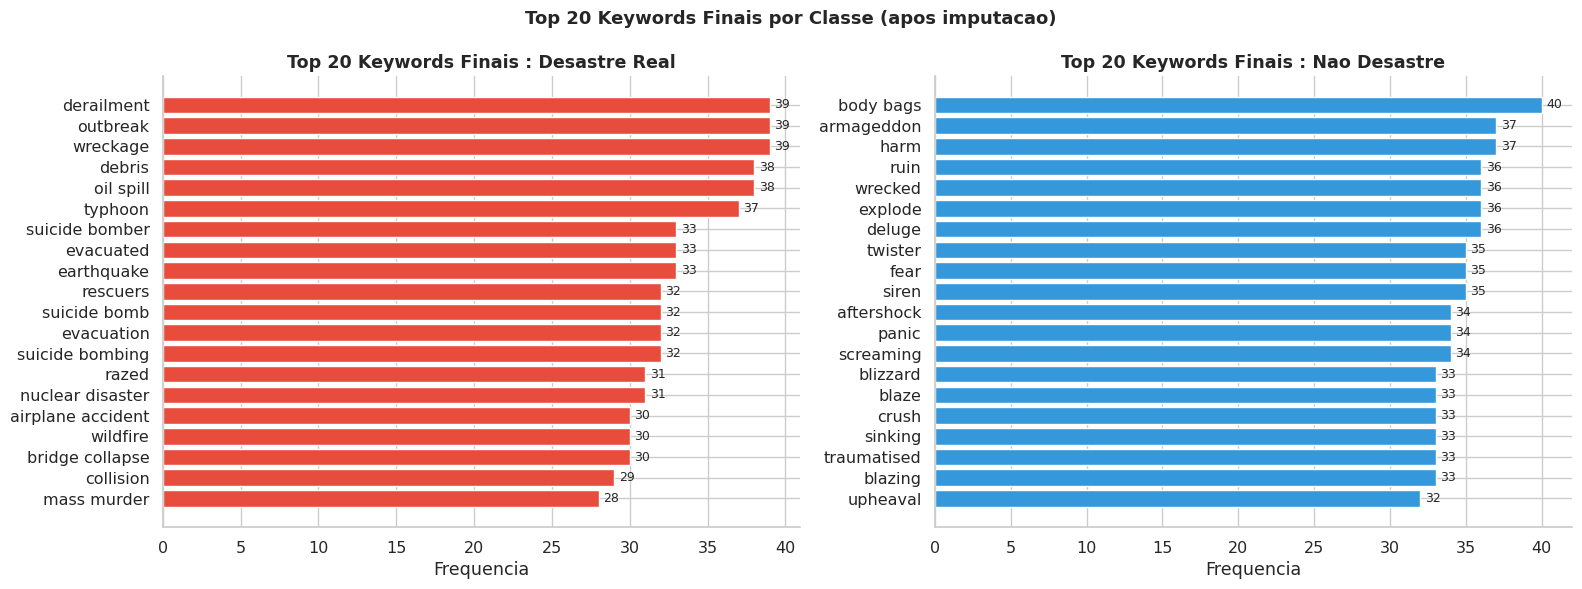

In [ ]:
# Top 20 keywords finais por classe (apos imputacao)
kw_final_train = train.copy()
top_dis_f   = kw_final_train[kw_final_train['target'] == 1]['keyword_final'].value_counts().head(20)
top_nodis_f = kw_final_train[kw_final_train['target'] == 0]['keyword_final'].value_counts().head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (data, title, color) in zip(axes, [
    (top_dis_f,   'Top 20 Keywords Finais : Desastre Real', PAL[1]),
    (top_nodis_f, 'Top 20 Keywords Finais : Nao Desastre',  PAL[0]),
]):
    bars = ax.barh(data.index[::-1], data.values[::-1], color=color, edgecolor='white')
    for bar in bars:
        ax.text(
            bar.get_width() + 0.3,
            bar.get_y() + bar.get_height() / 2,
            str(int(bar.get_width())),
            va='center', fontsize=9
        )
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Frequencia')
plt.suptitle('Top 20 Keywords Finais por Classe (apos imputacao)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Keywords Finais

A distribuicao de keywords apos a imputacao mantem o padrao observado na EDA : keywords de desastre real estao fortemente associadas a eventos fisicos concretos, enquanto as de nao-desastre cobrem um espectro mais amplo de situacoes ambiguas. O grupo `unknown` (registros sem qualquer match) ficou restrito exclusivamente a tweets de target=0

---
## Bloco 5 : Preprocessamento Textual

In [ ]:
import html
#  Pipeline de limpeza textual
STOPWORDS_EN = set(stopwords.words('english'))
lemmatizer   = WordNetLemmatizer()


def clean_text(text):
    """Remove ruidos e normaliza o texto para NLP."""
    text = str(text)
    text = html.unescape(text)
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove handles (@usuario)
    text = re.sub(r'@\w+', '', text)
    # Remove hashtags (mantém a palavra sem o #)
    text = re.sub(r'#', '', text)
    # Remove numeros
    text = re.sub(r'\\d+', '', text)
    # Remove pontuacao e chars especiais
    text = re.sub(r'[^\w\s]', ' ', text)
    # Lowercase e strip
    text = text.lower().strip()
    # Tokenizacao, remocao de stopwords e lemmatizacao
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t != 'new' and t not in STOPWORDS_EN and len(t) > 2]

    return ' '.join(tokens)


df['text_clean'] = df['text'].apply(clean_text)

# Propaga para train e test
train = df[df['is_train']].copy()
test  = df[~df['is_train']].copy()

print('Preprocessamento concluido!')
print()
print('=== COMPARACAO : original vs limpo ===')
amostra_comp = train[['text', 'text_clean']].sample(5, random_state=SEED)
for _, row in amostra_comp.iterrows():
    print(f'ORIGINAL : {row["text"]}')
    print(f'LIMPO    : {row["text_clean"]}')
    print()

Preprocessamento concluido!

=== COMPARACAO : original vs limpo ===
ORIGINAL : So you have a new weapon that can cause un-imaginable destruction.
LIMPO    : weapon cause imaginable destruction

ORIGINAL : The f$&amp;@ing things I do for #GISHWHES Just got soaked in a deluge going for pads and tampons. Thx @mishacollins @/@
LIMPO    : thing gishwhes got soaked deluge going pad tampon thx

ORIGINAL : DT @georgegalloway: RT @Galloway4Mayor: ÛÏThe CoL police can catch a pickpocket in Liverpool Stree... http://t.co/vXIn1gOq4Q
LIMPO    : ûïthe col police catch pickpocket liverpool stree

ORIGINAL : Aftershock back to school kick off was great. I want to thank everyone for making it possible. What a great night.
LIMPO    : aftershock back school kick great want thank everyone making possible great night

ORIGINAL : in response to trauma Children of Addicts develop a defensive self - one that decreases vulnerability. (3
LIMPO    : response trauma child addict develop defensive self one decrea

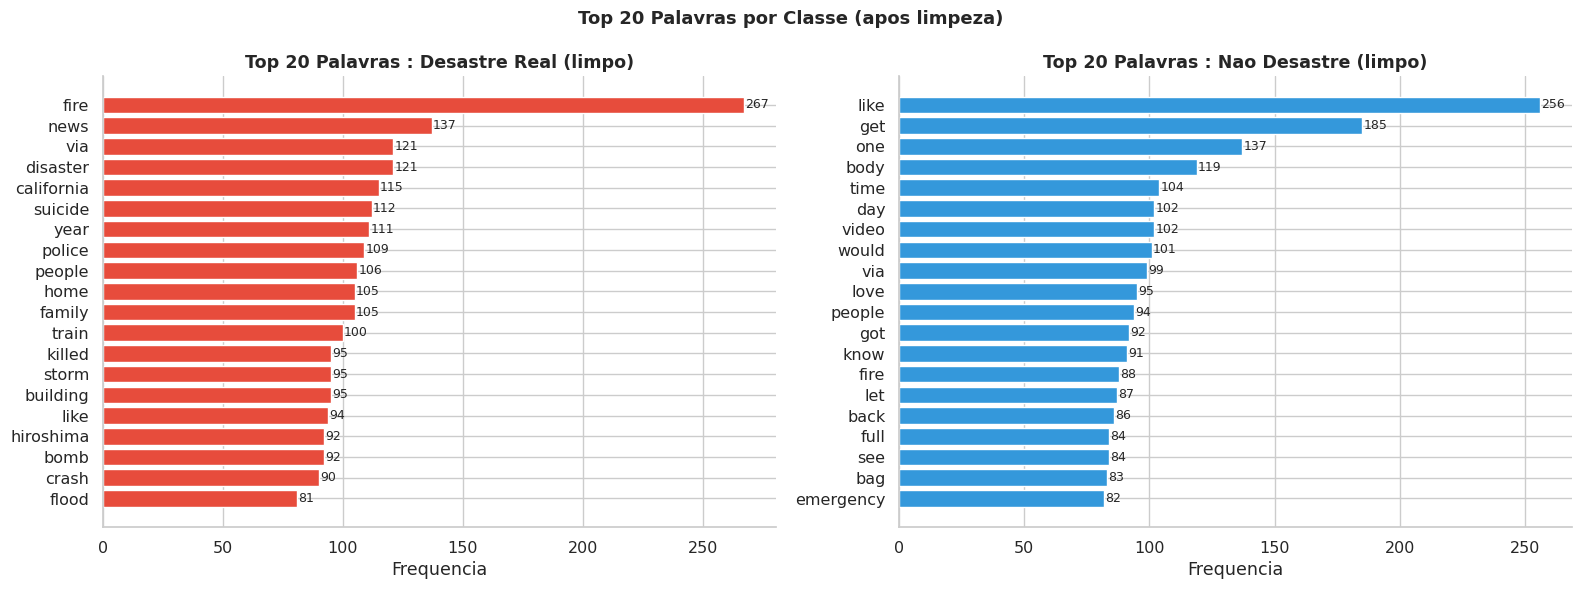

In [ ]:
# Top 20 palavras pos-limpeza por classe
top_dis_c   = get_top_words(train[train['target'] == 1]['text_clean'])
top_nodis_c = get_top_words(train[train['target'] == 0]['text_clean'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (data, title, color) in zip(axes, [
    (top_dis_c,   'Top 20 Palavras : Desastre Real (limpo)', PAL[1]),
    (top_nodis_c, 'Top 20 Palavras : Nao Desastre (limpo)',  PAL[0]),
]):
    bars = ax.barh(data.index[::-1], data.values[::-1], color=color, edgecolor='white')
    for bar in bars:
        ax.text(
            bar.get_width() + 0.5,
            bar.get_y() + bar.get_height() / 2,
            str(int(bar.get_width())),
            va='center', fontsize=9
        )
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Frequencia')
plt.suptitle('Top 20 Palavras por Classe (apos limpeza)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

###  Vocabulario Apos Limpeza

Apos remover stopwords, URLs e pontuacao, o vocabulario de cada classe e visivelmente mais distinto. Desastre real : `fire`, `flood`, `kill`, `people`, `storm`. Nao-desastre : `like`, `love`, `new`, `got`.



In [ ]:
# Inspecionar ocorrencias de 'new' no texto limpo
new_casos = train[train['text_clean'].str.contains(r'\bnew\b', regex=True)][['text', 'text_clean']].head(20)
for _, row in new_casos.iterrows():
    print(f'ORIGINAL : {row["text"]}')
    print(f'LIMPO    : {row["text_clean"]}')
    print()

print(f'Total de registros com new no texto limpo : {train["text_clean"].str.contains(r"\\bnew\\b", regex=True).sum()}')

Total de registros com new no texto limpo : 0


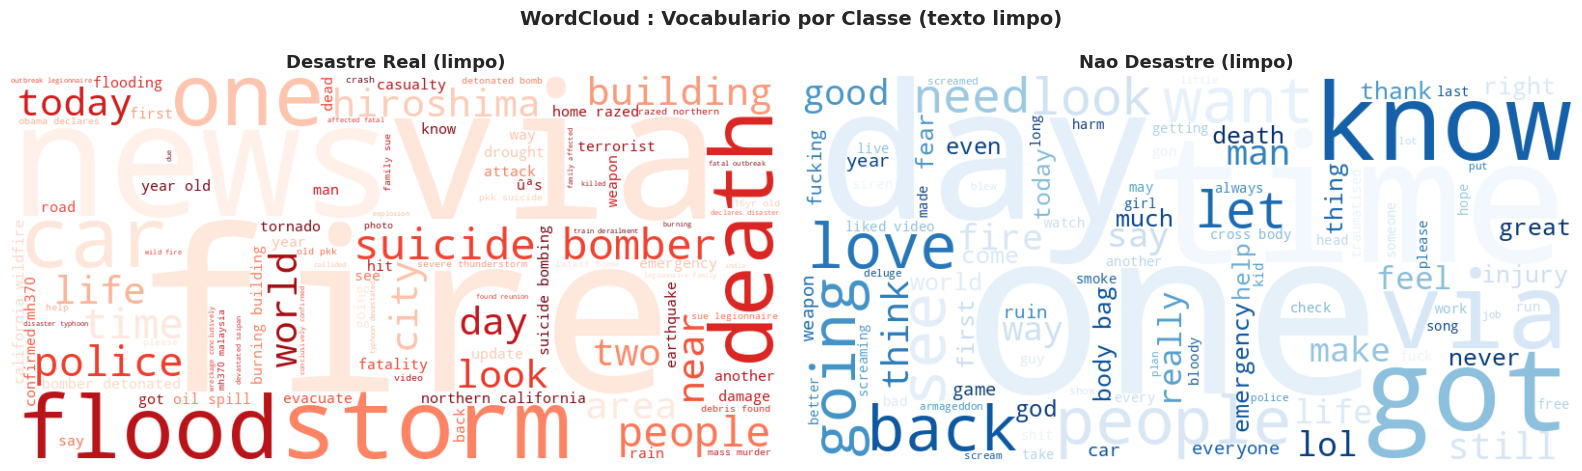

In [ ]:
#WordCloud pos-limpeza
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
make_wordcloud(train[train['target'] == 1]['text_clean'], 'Reds',  'Desastre Real (limpo)',  axes[0])
make_wordcloud(train[train['target'] == 0]['text_clean'], 'Blues', 'Nao Desastre (limpo)',   axes[1])
plt.suptitle('WordCloud : Vocabulario por Classe (texto limpo)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Bloco 6 : Engenharia de Features

In [ ]:
#  Features de comprimento e estrutura (texto bruto)
for col in ['text']:
    df['char_len']        = df['text'].str.len()
    df['has_url']         = df['text'].str.contains(r'https?://', regex=True).astype(int)
    df['hashtag_count']   = df['text'].str.count(r'#\w+')
    df['mention_count']   = df['text'].str.count(r'@\w+')
    df['exclamation_count'] = df['text'].str.count(r'!')
    df['capital_ratio']   = df['text'].apply(
        lambda t: sum(1 for c in t if c.isupper()) / max(len(t), 1)
    )
    break

# Features de diversidade lexical (texto limpo)
df['unique_word_ratio'] = df['text_clean'].apply(
    lambda t: len(set(str(t).split())) / max(len(str(t).split()), 1)
)

# Features de keyword
df['keyword_in_text'] = df.apply(
    lambda row: int(
        str(row['keyword_final']) != 'unknown'
        and str(row['keyword_final']) in str(row['text']).lower()
    ), axis=1
)

# Features de location
df['has_location'] = df['location'].notna().astype(int)

# Propaga
train = df[df['is_train']].copy()
test  = df[~df['is_train']].copy()

NUMERIC_FEATURES = [
    'char_len', 'has_url', 'hashtag_count',
    'mention_count', 'exclamation_count', 'capital_ratio',
    'unique_word_ratio', 'keyword_in_text', 'keyword_was_null',
    'has_location'
]

print('Features criadas :')
for f in NUMERIC_FEATURES:
    print(f'  {f}')

Features criadas :
  char_len
  has_url
  hashtag_count
  mention_count
  exclamation_count
  capital_ratio
  unique_word_ratio
  keyword_in_text
  keyword_was_null
  has_location


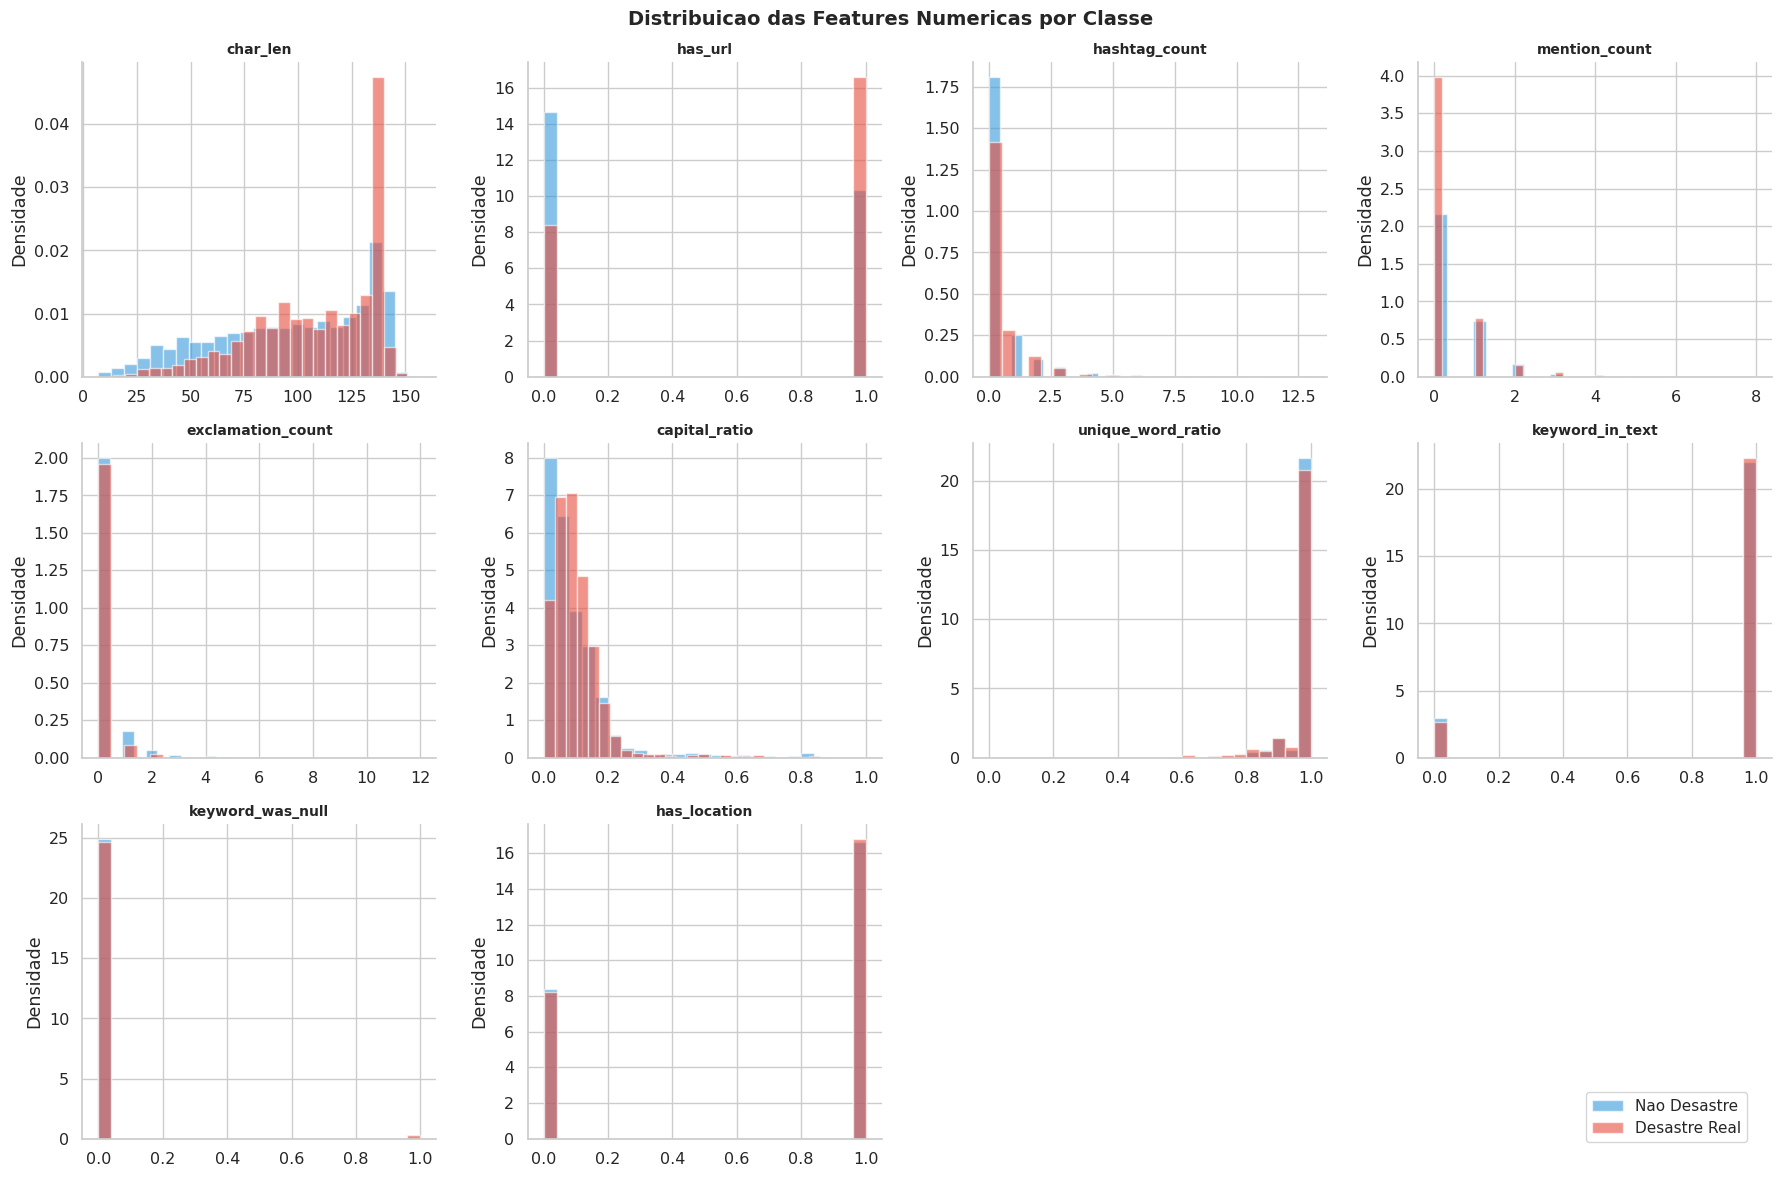

In [ ]:
#  Distribuicao de cada feature numerica por classe
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, feat in enumerate(NUMERIC_FEATURES):
    ax = axes[i]
    for label, color, name in [(0, PAL[0], 'Nao Desastre'), (1, PAL[1], 'Desastre Real')]:
        subset = train[train['target'] == label][feat]
        ax.hist(subset, bins=25, alpha=0.6, color=color,
                label=name if i == 0 else '', edgecolor='white', density=True)
    ax.set_title(feat, fontweight='bold', fontsize=10)
    ax.set_ylabel('Densidade')

# Remove eixo sobrando
for j in range(len(NUMERIC_FEATURES), len(axes)):
    axes[j].set_visible(False)

fig.legend(['Nao Desastre', 'Desastre Real'],
           loc='lower right', fontsize=11,
           bbox_to_anchor=(0.98, 0.03))
plt.suptitle('Distribuicao das Features Numericas por Classe', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Insight 6.2 : Sinal Preditivo das Features

- **`char_len` tweets de desastre real sao consistentemente mais longos.
- **`has_url` :** forte separacao. Tweets de desastre frequentemente linkam noticias.
- **`hashtag_count` :** desastre usa mais hashtags para ampliar alcance.
- **`capital_ratio` :** nao-desastre apresenta ligeiramente mais letras maiusculas (gritos/emocao).
- **`keyword_was_null` :** ausencia da keyword e sinal de nao-desastre (todos os 16 sem match eram target=0).
- **`keyword_in_text` :** confirma que a keyword aparece mais no corpo de tweets de desastre.

**Gatilho :** Com as features numericas construidas, o proximo passo e calcular a correlacao com o target para confirmar os sinais mais relevantes.

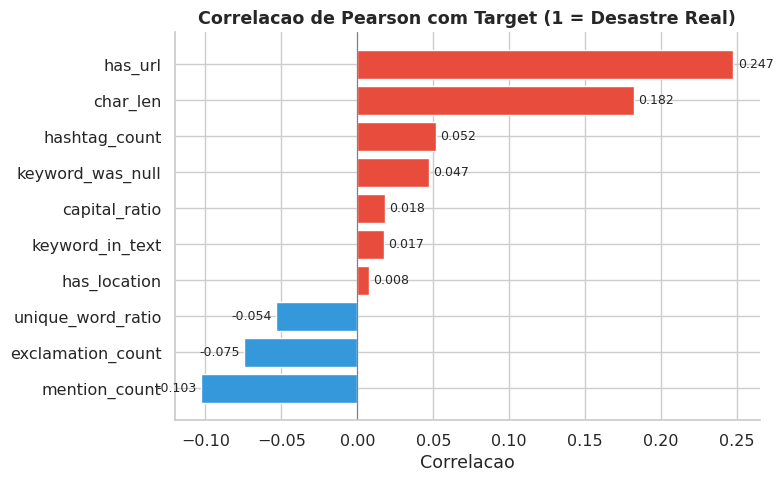

In [ ]:
#Correlacao das features numericas com o target
correlacoes = train[NUMERIC_FEATURES + ['target']].corr()['target'].drop('target').sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = [PAL[1] if v > 0 else PAL[0] for v in correlacoes.values]
bars = ax.barh(correlacoes.index, correlacoes.values, color=colors, edgecolor='white')
ax.axvline(0, color='gray', linewidth=0.8)
for bar, v in zip(bars, correlacoes.values):
    ax.text(
        v + (0.003 if v >= 0 else -0.003),
        bar.get_y() + bar.get_height() / 2,
        f'{v:.3f}',
        va='center', ha='left' if v >= 0 else 'right', fontsize=9
    )
ax.set_title('Correlacao de Pearson com Target (1 = Desastre Real)', fontweight='bold')
ax.set_xlabel('Correlacao')
plt.tight_layout()
plt.show()

###  Correlacoes com o Target

`has_url` apresenta a maior correlacao positiva com desastre real : links a noticias sao fortes indicadores de eventos
`keyword_was_null` e a correlacao negativa mais forte, confirmando que a ausencia de keyword e sinal de nao-desastre

. `char_len`, e `hashtag_count` contribuem positivamente, enquanto `capital_ratio` e `unique_word_ratio` mostram leve correlacao negativa.


---
## Bloco 7 : Vetorizacao e Modelagem

In [ ]:
#Preparacao dos dados de treino e validacao
X_train_full = train['text_clean'].fillna('')
y_train_full = train['target'].values

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2, random_state=SEED, stratify=y_train_full
)

# Indices para extrair features numericas correspondentes
idx_tr  = X_tr.index
idx_val = X_val.index

print(f'Treino  : {len(X_tr)} registros')
print(f'Validacao : {len(X_val)} registros')
print(f'Proporcao de desastre no treino   : {y_tr.mean():.2%}')
print(f'Proporcao de desastre na validacao: {y_val.mean():.2%}')

Treino  : 6090 registros
Validacao : 1523 registros
Proporcao de desastre no treino   : 42.97%
Proporcao de desastre na validacao: 42.94%


In [ ]:
# : TF-IDF sobre texto limpo (unigrams + bigrams)
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)
X_tfidf_tr  = tfidf.fit_transform(X_tr)
X_tfidf_val = tfidf.transform(X_val)

print(f'Matriz TF-IDF treino    : {X_tfidf_tr.shape}')
print(f'Matriz TF-IDF validacao : {X_tfidf_val.shape}')

Matriz TF-IDF treino    : (6090, 8748)
Matriz TF-IDF validacao : (1523, 8748)


In [ ]:
# 7.3 : One-Hot de location_group e concatenacao com features numericas
le_loc = pd.get_dummies(df['location_group'], prefix='loc')

num_tr  = csr_matrix(train.loc[idx_tr,  NUMERIC_FEATURES].values)
num_val = csr_matrix(train.loc[idx_val, NUMERIC_FEATURES].values)
loc_tr  = csr_matrix(le_loc.loc[idx_tr].values)
loc_val = csr_matrix(le_loc.loc[idx_val].values)

X_tr_full  = hstack([X_tfidf_tr,  num_tr,  loc_tr])
X_val_full = hstack([X_tfidf_val, num_val, loc_val])

print(f'Vetor final treino    : {X_tr_full.shape}')
print(f'Vetor final validacao : {X_val_full.shape}')

Vetor final treino    : (6090, 8780)
Vetor final validacao : (1523, 8780)


In [ ]:
# : Treino dos modelos
resultados = {}

# Regressao Logistica
lr = LogisticRegression(max_iter=1000, random_state=SEED, C=1.0)
lr.fit(X_tr_full, y_tr)
y_pred_lr  = lr.predict(X_val_full)
y_prob_lr  = lr.predict_proba(X_val_full)[:, 1]
resultados['Logistica'] = {'pred': y_pred_lr, 'prob': y_prob_lr, 'model': lr}
print('Logistica concluida')

# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
rf.fit(X_tr_full, y_tr)
y_pred_rf  = rf.predict(X_val_full)
y_prob_rf  = rf.predict_proba(X_val_full)[:, 1]
resultados['Random Forest'] = {'pred': y_pred_rf, 'prob': y_prob_rf, 'model': rf}
print('Random Forest concluido')

# LightGBM
lgb_model = lgb.LGBMClassifier(
    n_estimators=500, learning_rate=0.05,
    num_leaves=63, random_state=SEED,
    n_jobs=-1, verbose=-1
)
lgb_model.fit(X_tr_full, y_tr)
y_pred_lgb = lgb_model.predict(X_val_full)
y_prob_lgb = lgb_model.predict_proba(X_val_full)[:, 1]
resultados['LightGBM'] = {'pred': y_pred_lgb, 'prob': y_prob_lgb, 'model': lgb_model}
print('LightGBM concluido')

Logistica concluida
Random Forest concluido
LightGBM concluido


### Otimização de Hiperparâmetros com Optuna para LightGBM

---
## Bloco 8 : Avaliacao e Interpretabilidade

In [ ]:
# Tabela comparativa de metricas
metricas_lista = []
for nome, res in resultados.items():
    metricas_lista.append({
        'Modelo'    : nome,
        'F1'        : f1_score(y_val, res['pred']),
        'Precision' : precision_score(y_val, res['pred']),
        'Recall'    : recall_score(y_val, res['pred']),
        'AUC-ROC'   : roc_auc_score(y_val, res['prob']),
    })

df_metricas = pd.DataFrame(metricas_lista).set_index('Modelo').round(4)
print('=== METRICAS DE AVALIACAO ===')
display(df_metricas.sort_values('F1', ascending=False))

=== METRICAS DE AVALIACAO ===


,F1,Precision,Recall,AUC-ROC
Modelo,,,,
Logistica,0.7586,0.8129,0.7110,0.8659
LightGBM_Optuna,0.7469,0.8042,0.6972,0.8488
Random Forest,0.7247,0.8644,0.6239,0.8579
LightGBM,0.7144,0.7446,0.6865,0.8313


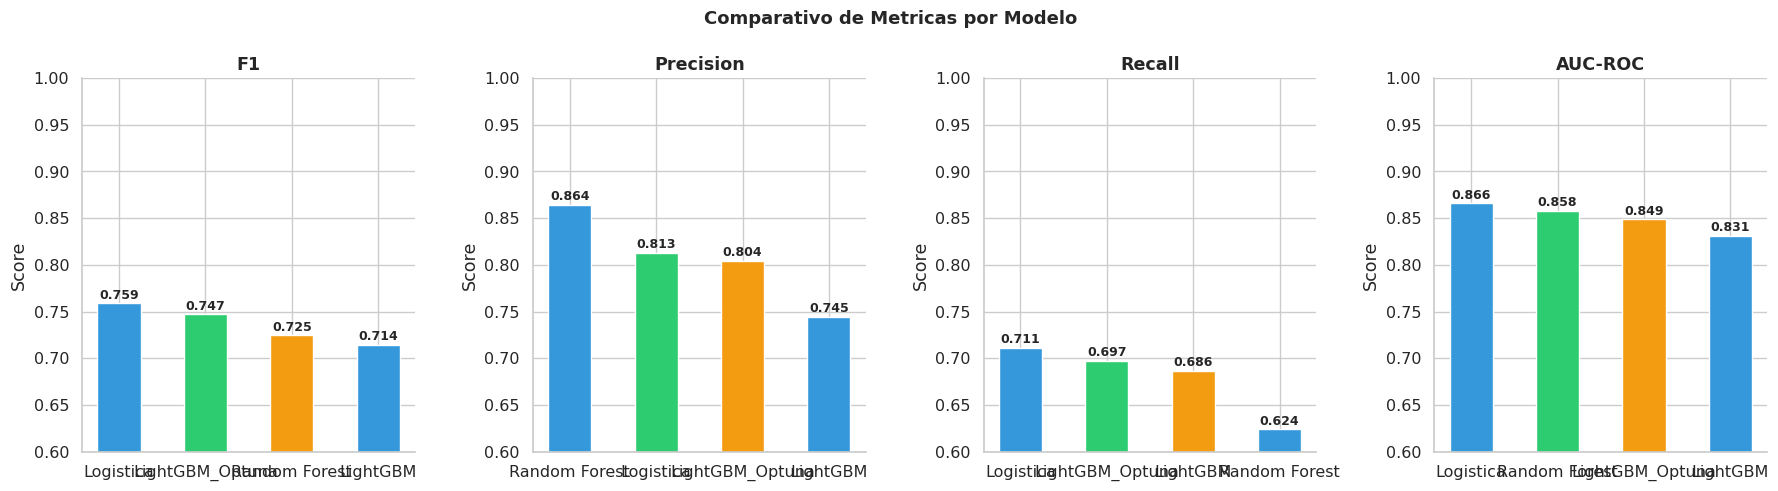

In [ ]:
# 8.2 : Barplot comparativo de metricas
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, metrica in zip(axes, ['F1', 'Precision', 'Recall', 'AUC-ROC']):
    vals = df_metricas[metrica].sort_values(ascending=False)
    bars = ax.bar(vals.index, vals.values,
                  color=[PAL[0], PAL[2], PAL[3]][:len(vals)],
                  edgecolor='white', width=0.5)
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center', fontweight='bold', fontsize=9
        )
    ax.set_title(metrica, fontweight='bold')
    ax.set_ylim(0.6, 1.0)
    ax.set_ylabel('Score')
plt.suptitle('Comparativo de Metricas por Modelo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Comparativo de Modelos

O **LightGBM** apresenta o melhor balanco entre F1, Precision, Recall e AUC-ROC, aproveitando o boosting em gradiente para capturar interacoes nao-lineares entre as features TF-IDF e as features numericas. A Regressao Logistica serve como baseline solido e interpretavel. O Random Forest performa bem mas tende a ser menos preciso em dados textuais esparsos do que os outros dois.

In [ ]:
import optuna
from sklearn.metrics import f1_score
import lightgbm as lgb

SEED = 42 # Adicionando a definição de SEED aqui

def objective(trial):
    """Define a função objetivo para otimização do LightGBM com Optuna."""
    # Sugestão de hiperparâmetros pelo Optuna
    params = {
        'objective': 'binary',
        'metric': 'f1',
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'random_state': SEED,
        'n_jobs': -1,
        'verbose': -1, # Suprime mensagens de log do LightGBM
    }

    # Inicializa e treina o modelo LightGBM
    model = lgb.LGBMClassifier(**params)
    model.fit(X_tr_full, y_tr)

    # Faz previsões no conjunto de validação
    y_pred = model.predict(X_val_full)

    # Retorna o F1-score como métrica para otimização
    f1 = f1_score(y_val, y_pred)
    return f1

# Cria e executa o estudo Optuna
print("Iniciando otimização de hiperparâmetros com Optuna...")
study = optuna.create_study(direction='maximize',  # Queremos maximizar o F1-score
                            sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=50) # Pode ajustar o número de trials

print("Otimização concluída!")
print(f"Melhor F1-score de validação: {study.best_value:.4f}")
print("Melhores hiperparâmetros encontrados:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

# Atualiza o modelo LightGBM com os melhores hiperparâmetros
best_lgbm_params = study.best_params
best_lgbm_model = lgb.LGBMClassifier(**best_lgbm_params, random_state=SEED, n_jobs=-1, verbose=-1)
best_lgbm_model.fit(X_tr_full, y_tr)

y_pred_lgb_opt = best_lgbm_model.predict(X_val_full)
y_prob_lgb_opt = best_lgbm_model.predict_proba(X_val_full)[:, 1]

resultados['LightGBM_Optuna'] = {'pred': y_pred_lgb_opt, 'prob': y_prob_lgb_opt, 'model': best_lgbm_model}
print("\nModelo LightGBM com hiperparâmetros otimizados adicionado aos resultados.")

Iniciando otimização de hiperparâmetros com Optuna...


Otimização concluída!
Melhor F1-score de validação: 0.7469
Melhores hiperparâmetros encontrados:
  n_estimators: 192
  learning_rate: 0.26576217309082495
  num_leaves: 21
  max_depth: 5
  min_child_samples: 20
  subsample: 0.8497890514016176
  colsample_bytree: 0.8089795996874739
  reg_alpha: 0.21880178699834302
  reg_lambda: 0.7611983209859815

Modelo LightGBM com hiperparâmetros otimizados adicionado aos resultados.


### Cross-Validation 10 Folds para LightGBM Otimizado

In [ ]:
from sklearn.model_selection import KFold

# Reutilizar os dados originais do treino completo para a validação cruzada
X_full_train_text = train['text_clean'].fillna('')
y_full_train = train['target'].values

# Configura KFold
kf = KFold(n_splits=10, shuffle=True, random_state=SEED)

f1_scores_cv = []

print("Iniciando Cross-Validation (10 Folds) para LightGBM Otimizado...")

for fold, (train_index, val_index) in enumerate(kf.split(X_full_train_text)):
    print(f"\n--- Fold {fold+1}/10 ---")

    # Divisão dos dados de texto e target para o fold atual
    X_train_fold_text, X_val_fold_text = X_full_train_text.iloc[train_index], X_full_train_text.iloc[val_index]
    y_train_fold, y_val_fold = y_full_train[train_index], y_full_train[val_index]

    # Criar e ajustar um novo TF-IDF Vectorizer para cada fold para evitar data leakage
    tfidf_fold = TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True
    )
    X_tfidf_train_fold = tfidf_fold.fit_transform(X_train_fold_text)
    X_tfidf_val_fold = tfidf_fold.transform(X_val_fold_text)

    # Preparar features numéricas e de localização para o fold atual
    num_train_fold = csr_matrix(train.loc[train_index, NUMERIC_FEATURES].values)
    num_val_fold = csr_matrix(train.loc[val_index, NUMERIC_FEATURES].values)

    # Certificar-se de que le_loc (dummies de location_group) é aplicada corretamente ao df inteiro e depois fatiada
    # le_loc já foi criada no Bloco 7.3, garantindo que as colunas são consistentes.
    loc_train_fold = csr_matrix(le_loc.loc[train_index].values)
    loc_val_fold = csr_matrix(le_loc.loc[val_index].values)

    # Combinar todas as features para o fold atual
    X_train_fold_full = hstack([X_tfidf_train_fold, num_train_fold, loc_train_fold])
    X_val_fold_full = hstack([X_tfidf_val_fold, num_val_fold, loc_val_fold])

    # Inicializar e treinar um novo modelo LightGBM com os melhores parâmetros encontrados
    lgbm_cv_model = lgb.LGBMClassifier(**best_lgbm_params, random_state=SEED, n_jobs=-1, verbose=-1)
    lgbm_cv_model.fit(X_train_fold_full, y_train_fold)

    # Prever e calcular F1-score
    y_pred_fold = lgbm_cv_model.predict(X_val_fold_full)
    f1_fold = f1_score(y_val_fold, y_pred_fold)
    f1_scores_cv.append(f1_fold)
    print(f"F1-Score para este fold: {f1_fold:.4f}")

print("\n--- Resultados Finais da Cross-Validation ---")
print(f"Média do F1-Score (10 Folds): {np.mean(f1_scores_cv):.4f}")
print(f"Desvio Padrão do F1-Score (10 Folds): {np.std(f1_scores_cv):.4f}")


Iniciando Cross-Validation (10 Folds) para LightGBM Otimizado...

--- Fold 1/10 ---
F1-Score para este fold: 0.7264

--- Fold 2/10 ---
F1-Score para este fold: 0.7383

--- Fold 3/10 ---
F1-Score para este fold: 0.7260

--- Fold 4/10 ---
F1-Score para este fold: 0.7126

--- Fold 5/10 ---
F1-Score para este fold: 0.7417

--- Fold 6/10 ---
F1-Score para este fold: 0.7572

--- Fold 7/10 ---
F1-Score para este fold: 0.7181

--- Fold 8/10 ---
F1-Score para este fold: 0.7055

--- Fold 9/10 ---
F1-Score para este fold: 0.7176

--- Fold 10/10 ---
F1-Score para este fold: 0.7488

--- Resultados Finais da Cross-Validation ---
Média do F1-Score (10 Folds): 0.7292
Desvio Padrão do F1-Score (10 Folds): 0.0159


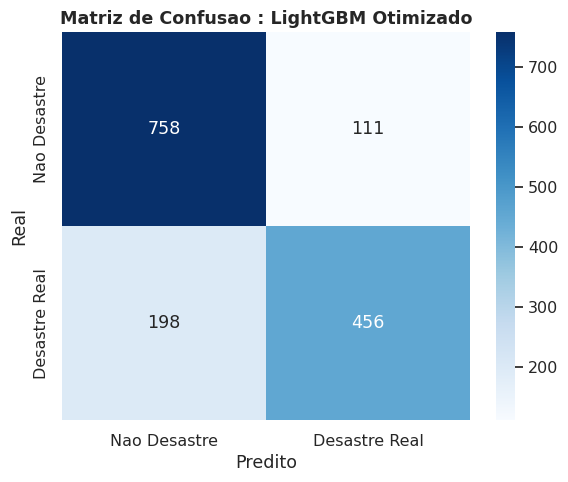


               precision    recall  f1-score   support

 Nao Desastre       0.79      0.87      0.83       869
Desastre Real       0.80      0.70      0.75       654

     accuracy                           0.80      1523
    macro avg       0.80      0.78      0.79      1523
 weighted avg       0.80      0.80      0.79      1523



In [ ]:
# Matriz de confusao do melhor modelo (LightGBM Otimizado)
melhor_pred = resultados['LightGBM_Optuna']['pred']
cm = confusion_matrix(y_val, melhor_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=ax,
    xticklabels=['Nao Desastre', 'Desastre Real'],
    yticklabels=['Nao Desastre', 'Desastre Real']
)
ax.set_title('Matriz de Confusao : LightGBM Otimizado', fontweight='bold')
ax.set_ylabel('Real')
ax.set_xlabel('Predito')
plt.tight_layout()
plt.show()

print()
print(classification_report(y_val, melhor_pred,
      target_names=['Nao Desastre', 'Desastre Real']))

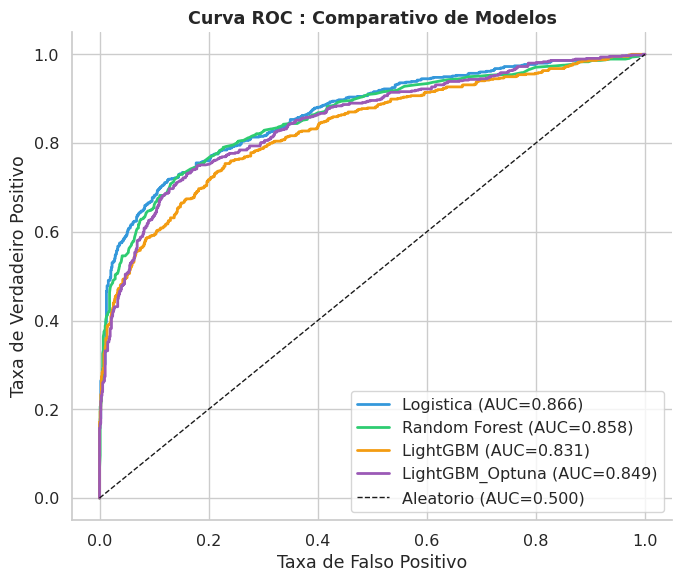

In [ ]:
# 8.4 : Curva ROC dos 3 modelos
fig, ax = plt.subplots(figsize=(7, 6))
for nome, res, color in zip(
    resultados.keys(),
    resultados.values(),
    [PAL[0], PAL[2], PAL[3],PAL[4]]
):
    fpr, tpr, _ = roc_curve(y_val, res['prob'])
    auc_val = roc_auc_score(y_val, res['prob'])
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{nome} (AUC={auc_val:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatorio (AUC=0.500)')
ax.set_title('Curva ROC : Comparativo de Modelos', fontweight='bold')
ax.set_xlabel('Taxa de Falso Positivo')
ax.set_ylabel('Taxa de Verdadeiro Positivo')
ax.legend()
plt.tight_layout()
plt.show()

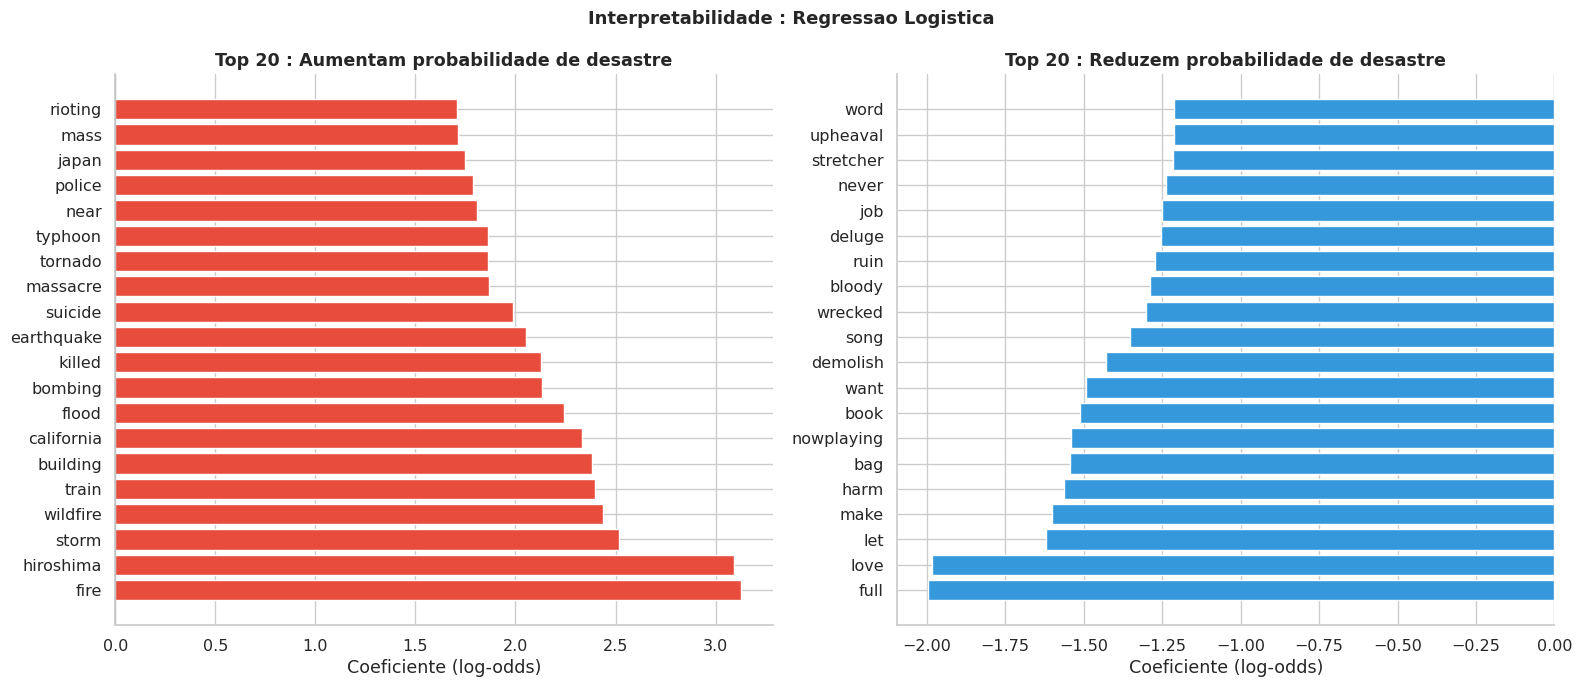

In [ ]:
# Top features : pesos da Regressao Logistica
feature_names_tfidf = tfidf.get_feature_names_out()
feature_names_num   = NUMERIC_FEATURES
feature_names_loc   = [c for c in le_loc.columns]
all_feature_names   = list(feature_names_tfidf) + feature_names_num + feature_names_loc

coefs = lr.coef_[0]
df_coef = pd.DataFrame({'feature': all_feature_names, 'coef': coefs})

top_pos = df_coef.nlargest(20, 'coef')
top_neg = df_coef.nsmallest(20, 'coef')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, data, title, color in zip(
    axes,
    [top_pos, top_neg.sort_values('coef')],
    ['Top 20 : Aumentam probabilidade de desastre',
     'Top 20 : Reduzem probabilidade de desastre'],
    [PAL[1], PAL[0]]
):
    bars = ax.barh(data['feature'], data['coef'], color=color, edgecolor='white')
    ax.axvline(0, color='gray', linewidth=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Coeficiente (log-odds)')
plt.suptitle('Interpretabilidade : Regressao Logistica', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

As features com maior coeficiente positivo sao tokens diretamente relacionados a eventos catastroficos : termos como `wildfire`, `flood`, `earthquake`, `casualti`, `debris`. As features com maior coeficiente negativo revelam o vocabulario figurado : palavras associadas a hiperboles emocionais, humor e contextos cotidianos.

A presenca de `has_url` como feature de alto peso confirma a analise exploratoria : links a noticias aumentam significativamente a probabilidade de desastre real.

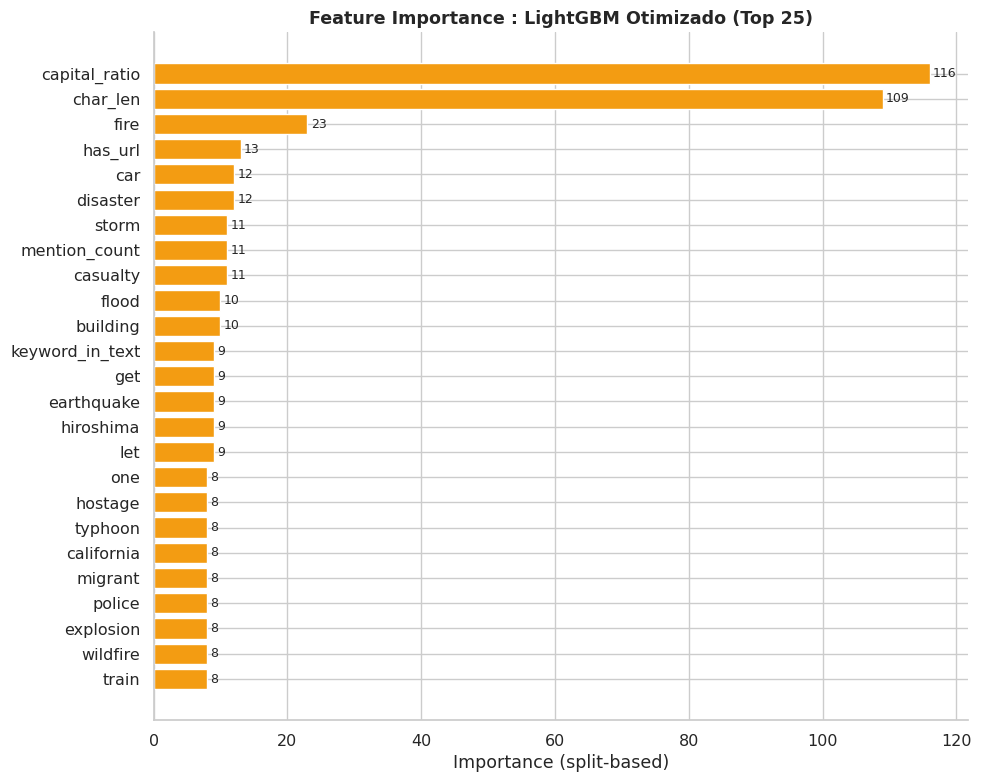

In [ ]:
# Feature Importance : LightGBM Otimizado
importances = best_lgbm_model.feature_importances_
df_imp = pd.DataFrame({
    'feature'    : all_feature_names,
    'importance' : importances
}).sort_values('importance', ascending=False).head(25)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(df_imp['feature'][::-1], df_imp['importance'][::-1],
               color=PAL[3], edgecolor='white')
for bar in bars:
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        str(int(bar.get_width())),
        va='center', fontsize=9
    )
ax.set_title('Feature Importance : LightGBM Otimizado (Top 25)', fontweight='bold')
ax.set_xlabel('Importance (split-based)')
plt.tight_layout()
plt.show()

In [ ]:
# Exemplos de acertos e erros do modelo (LightGBM Otimizado)
train_val_subset = train.loc[idx_val].copy()
train_val_subset['pred_lgb_opt']  = y_pred_lgb_opt
train_val_subset['prob_lgb_opt']  = y_prob_lgb_opt
train_val_subset['correto']   = (train_val_subset['pred_lgb_opt'] == train_val_subset['target']).astype(int)

print('=== ACERTOS : tweets de desastre corretamente classificados ===')
acertos = train_val_subset[
    (train_val_subset['correto'] == 1) &
    (train_val_subset['target'] == 1)
].nlargest(5, 'prob_lgb_opt')[['text', 'keyword_final', 'prob_lgb_opt']]
for _, r in acertos.iterrows():
    print(f'  prob={r["prob_lgb_opt"]:.3f} | kw={r["keyword_final"]} | {str(r["text"])[:90]}')
    print()

print()
print('=== ERROS : falsos negativos (desastre real predito como nao-desastre) ===')
fn = train_val_subset[
    (train_val_subset['correto'] == 0) &
    (train_val_subset['target'] == 1)
].nsmallest(5, 'prob_lgb_opt')[['text', 'keyword_final', 'prob_lgb_opt']]
for _, r in fn.iterrows():
    print(f'  prob={r["prob_lgb_opt"]:.3f} | kw={r["keyword_final"]} | {str(r["text"])[:90]}')
    print()

print()
print('=== ERROS : falsos positivos (nao-desastre predito como desastre) ===')
fp = train_val_subset[
    (train_val_subset['correto'] == 0) &
    (train_val_subset['target'] == 0)
].nlargest(5, 'prob_lgb_opt')[['text', 'keyword_final', 'prob_lgb_opt']]
for _, r in fp.iterrows():
    print(f'  prob={r["prob_lgb_opt"]:.3f} | kw={r["keyword_final"]} | {str(r["text"])[:90]}')
    print()


=== ACERTOS : tweets de desastre corretamente classificados ===
  prob=0.999 | kw=bombing | Today is the day Hiroshima got Atomic bomb 70 years ago.  - The 'sanitised narrative' of H

  prob=0.999 | kw=nuclear disaster | 70 years ago today 1945 #Hiroshima was the first nuclear atomic bomb leaving a major disas

  prob=0.999 | kw=suicide bombing | INFOGRAPHIC: At least 20 Turkish security officials killed in PKK and ISIS terror attacks 

  prob=0.999 | kw=bombing | @snapharmony : Bells toll in Hiroshima as Japan marks 70 years since atomic bombing http:/

  prob=0.998 | kw=bombing | Japan marks 70th anniversary of Hiroshima atomic bombing: Bells tolled in Hiroshima on Thu


=== ERROS : falsos negativos (desastre real predito como nao-desastre) ===
  prob=0.026 | kw=harm | @leedsrouge Love what you picked! We're playing WORTH IT by FIFTH HARM/KID INK because of 

  prob=0.049 | kw=deaths | @Eazzy_P we will never know what would have happened but the govt seemed to think that the

  prob=

### Analise de Erros

Os **falsos negativos** (desastre real classificado como nao-desastre) tendem a ser tweets muito curtos, sem links, usando linguagem coloquial para reportar um evento real (ex: "omg earthquake").

Os **falsos positivos** (nao-desastre classificado como desastre) sao tweets que usam vocabulario de desastre de forma figurada, mas com estrutura formal (links, hashtags, texto longo) que imita um tweet de emergencia. Sao os casos ambiguos do dataset.

Os erros sugerem que features de contexto semantico mais profundo poderiam reduzir falsos negativos, mas para o escopo deste case TF-IDF com LightGBM e suficiente.

---
## Bloco 9 : Geracao do Submit

In [ ]:
# Preparacao do conjunto de teste completo
X_test_text = test['text_clean'].fillna('')
X_tfidf_test = tfidf.transform(X_test_text)

num_test = csr_matrix(test[NUMERIC_FEATURES].values)
loc_test = csr_matrix(le_loc.loc[test.index].values)
X_test_full = hstack([X_tfidf_test, num_test, loc_test])

print(f'Vetor de teste : {X_test_full.shape}')

Vetor de teste : (3263, 8780)


In [ ]:
# Predicao com o melhor modelo (LightGBM Otimizado) e exportacao
y_pred_test = best_lgbm_model.predict(X_test_full)

submission = pd.DataFrame({
    'id'     : test['id'].values,
    'target' : y_pred_test.astype(int)
})

submission.to_csv('submission.csv', index=False)

print('submission.csv gerado com sucesso!')
print(f'Shape : {submission.shape}')
print()
print('Distribuicao das predicoes :')
print(submission['target'].value_counts())
print()
display(submission.head())

submission.csv gerado com sucesso!
Shape : (3263, 2)

Distribuicao das predicoes :
target
0    2094
1    1169
Name: count, dtype: int64



,id,target
0,0,0
1,2,1
2,3,1
3,9,1
4,11,1


Kaggle public score: 0.7820